## FIFA Players Performance Analysis
Two linked assignments on one FIFA dataset (`Fifa.csv`, ~19.7k players): EDA → classical ML baselines (Regression + Classification) → tuned models, ensembles, and a final production-style `sklearn` pipeline.

- **Regression target:** `Value Per M$` (player market value, log-transformed)
- **Classification target:** `performance Tier` (`Low`/`Mid`/`High`/`Elite`, derived from `Overall_Rating` quartiles)

`Overall_Rating` is excluded from all classification models (it's the source of the Tier label) but kept for regression. Categorical encoding for `Country`/`Team` is fit on `Overall_Rating`, never on the actual target — avoiding leakage.

See `README.md` for setup and full results.

In [ ]:
# all used imports
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, validation_curve,
      cross_val_score, KFold, StratifiedKFold,
        learning_curve, GridSearchCV
    )
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from category_encoders import TargetEncoder 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, LassoCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    VotingClassifier, VotingRegressor,
    StackingClassifier, StackingRegressor
    )
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    r2_score, mean_squared_error, mean_absolute_error
    )
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


---
## Task 1: Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
data = pd.read_csv("Fifa.csv")
original_df = data.copy()

data.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [3]:
# Number of rows and columns
data.shape

(19667, 9)

In [4]:
# Identify numerical and categorical features
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(include=['object', 'category','string']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical features: ['Name', 'Country', 'Position', 'Team']


In [5]:
# Check if there are any missing values at all
has_missing = data.isnull().values.any()
print(f"Any missing values? {has_missing}")

Any missing values? False


In [6]:
# Count missing values per column
missing_count = data.isnull().sum()
print("Missing values per column:")
print(missing_count)

Missing values per column:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


In [7]:
# Check duplicates
duplicates = data.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 0


In [8]:
data.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


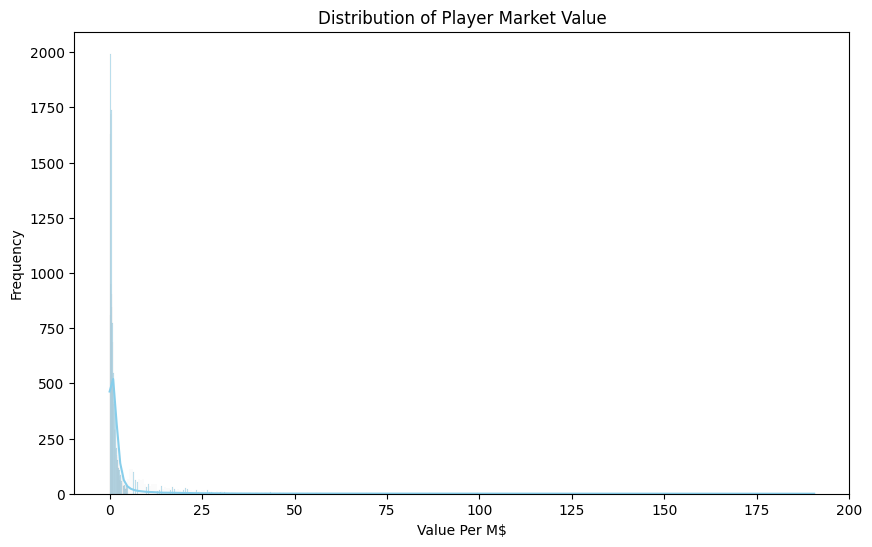

In [9]:
# Distribution of Value Per M$
plt.figure(figsize=(10, 6))
sns.histplot(data['Value Per M$'], kde=True, color='skyblue')
plt.title('Distribution of Player Market Value')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.show()

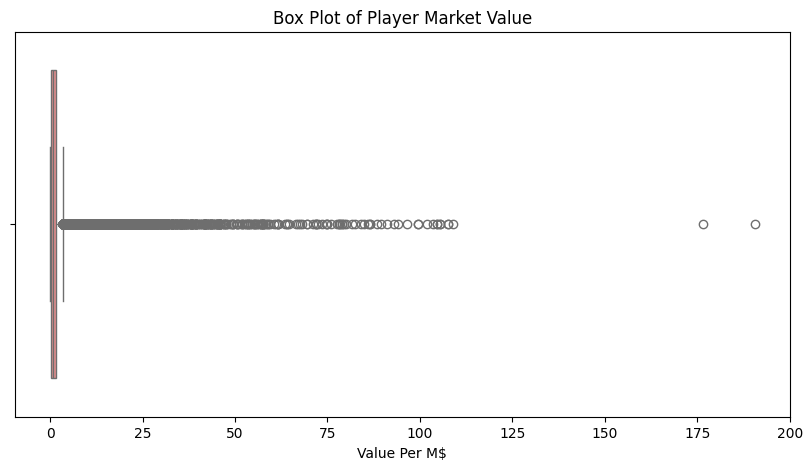

Skewness of Value Per M$: 7.9832


In [10]:
# Box plot of Value Per M$
plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Value Per M$'], color='lightcoral')
plt.title('Box Plot of Player Market Value')
plt.xlabel('Value Per M$')
plt.show()

print("Skewness of Value Per M$:", round(data['Value Per M$'].skew(), 4))

In [11]:
# Outlier detection using IQR for key numerical columns
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

outliers_info = {}
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    num_outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
    outliers_info[col] = num_outliers

print("--- Number of Outliers per Column ---")
for col, count in outliers_info.items():
    print(f"{col}: {count} outliers")

# No outliers were removed because they represent real-world values.
# Instead, log transformation will be applied to the target variable to handle skewness.


--- Number of Outliers per Column ---
Age: 169 outliers
Overall_Rating: 146 outliers
Future Potential: 120 outliers
Total_Stats Score: 788 outliers


In [12]:
# Average Overall_Rating per Position
avg_rating_per_position = data.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print("Average Overall_Rating per Position:")
print(avg_rating_per_position)

Average Overall_Rating per Position:
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


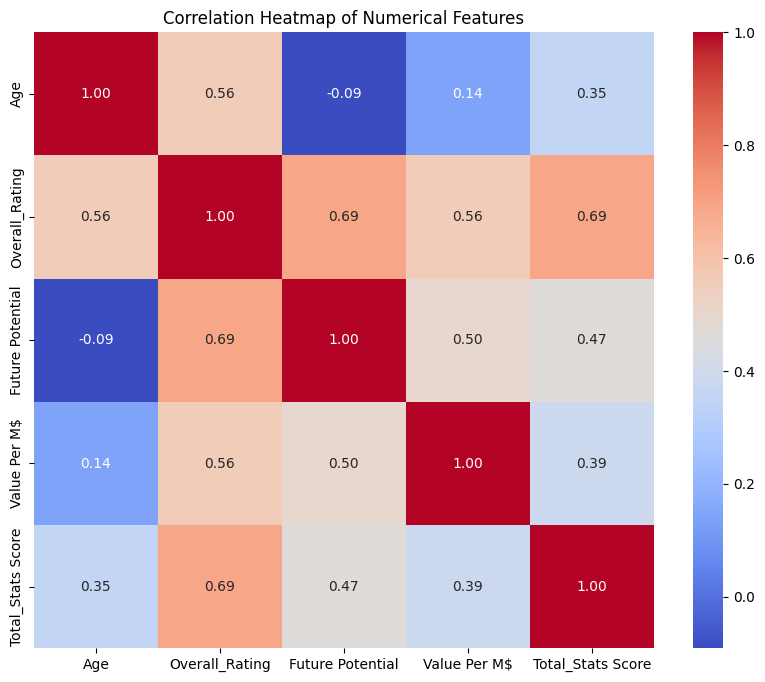


Correlation of features with Value Per M$:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [13]:
# Correlation heatmap
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("\nCorrelation of features with Value Per M$:")
print(corr['Value Per M$'].sort_values(ascending=False))

---
## Task 2: Data Preprocessing

In [14]:
# Step 1: Create Performance Tier (classification target)
# Using data-driven thresholds based on quartiles of Overall_Rating
q1 = data['Overall_Rating'].quantile(0.25)  # 58
q2 = data['Overall_Rating'].quantile(0.50)  # 63
q3 = data['Overall_Rating'].quantile(0.75)  # 68

print(f"Q1 = {q1}  |  Q2 (Median) = {q2}  |  Q3 = {q3}")

def create_tier(r):
    if r <= q1:   return 'Low'
    elif r <= q2: return 'Mid'
    elif r <= q3: return 'High'
    else:         return 'Elite'

data['performance Tier'] = data['Overall_Rating'].apply(create_tier)
print("\nTier distribution (before split):")
print(data['performance Tier'].value_counts())

Q1 = 58.0  |  Q2 (Median) = 63.0  |  Q3 = 68.0

Tier distribution (before split):
performance Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


In [15]:
# Define X
X = data.drop(columns=['Name', 'Value Per M$', 'performance Tier'], errors='ignore')

# Targets
y_reg = data['Value Per M$']
y_clf = data['performance Tier']

# Split
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# for Naive bayes
X_train_nb = X_train.copy().drop(['Overall_Rating'], axis=1)
X_test_nb = X_test.copy().drop(['Overall_Rating'], axis=1)

print("Train set size:", X_train.shape[0])
print("Test set size: ", X_test.shape[0])

Train set size: 15733
Test set size:  3934


### Encoding Categorical Features


In [16]:
# Target Encoding - Country & Team 
target_enc = TargetEncoder(cols=['Country', 'Team'], smoothing=10)
target_enc.fit(X_train[['Country', 'Team']], X_train['Overall_Rating'])

train_te = target_enc.transform(X_train[['Country', 'Team']]).add_suffix('_enc')
test_te  = target_enc.transform(X_test[['Country', 'Team']]).add_suffix('_enc')

X_train = pd.concat([X_train.drop(['Country', 'Team'], axis=1), train_te], axis=1)
X_test  = pd.concat([X_test.drop(['Country', 'Team'], axis=1),  test_te],  axis=1)

# One-Hot Encoding - Position
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[['Position']])

train_pos = encoder.transform(X_train[['Position']])
test_pos  = encoder.transform(X_test[['Position']])
pos_cols  = encoder.get_feature_names_out(['Position'])

X_train = pd.concat([X_train.drop('Position', axis=1),
                      pd.DataFrame(train_pos, columns=pos_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test.drop('Position', axis=1),
                      pd.DataFrame(test_pos, columns=pos_cols, index=X_test.index)], axis=1)

print(f"Final number of features: {X_train.shape[1]}")



Final number of features: 23


In [17]:
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0


In [18]:
# Step 5: Scale numerical features (fit on train only)
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score','Country_enc','Team_enc']

scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Numerical features scaled (StandardScaler).")
print("\nSample of processed X_train:")
display(X_train.head())

Numerical features scaled (StandardScaler).

Sample of processed X_train:


,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_enc,Team_enc,Position_CAM,Position_CB,Position_CDM,Position_CF,...,Position_LM,Position_LW,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW
6536,0.643428,1.246990,0.514996,1.399205,0.935638,1.845432,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12474,-0.424765,-0.925617,-0.565822,-0.695087,-0.655924,-0.129860,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13565,-0.638403,-1.053417,-0.257017,-2.457958,1.010705,-0.019766,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19140,-0.852042,-1.181218,-0.411420,-1.001826,0.949707,1.117742,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15085,-0.852042,-0.670016,-0.411420,-0.504696,-0.655924,-0.433826,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Log Transformation of Regression Target

In [19]:
# Step 6: Log-transform regression target
y_train_reg_log = np.log1p(y_train_reg)
y_test_reg_log  = np.log1p(y_test_reg)

print("Original target range: [{:.2f}, {:.2f}]".format(y_train_reg.min(), y_train_reg.max()))
print("Log-transformed range: [{:.2f}, {:.2f}]".format(y_train_reg_log.min(), y_train_reg_log.max()))

Original target range: [0.00, 190.50]
Log-transformed range: [0.00, 5.25]


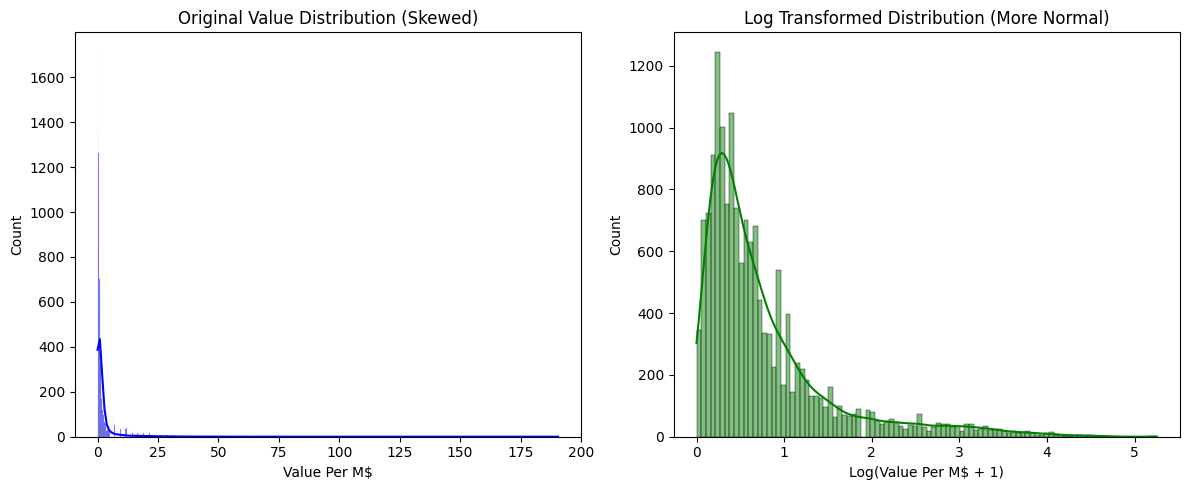

In [20]:
# Visualize effect of log transformation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_train_reg, kde=True, color='blue')
plt.title('Original Value Distribution (Skewed)')
plt.xlabel('Value Per M$')

plt.subplot(1, 2, 2)
sns.histplot(y_train_reg_log, kde=True, color='green')
plt.title('Log Transformed Distribution (More Normal)')
plt.xlabel('Log(Value Per M$ + 1)')

plt.tight_layout()
plt.show()

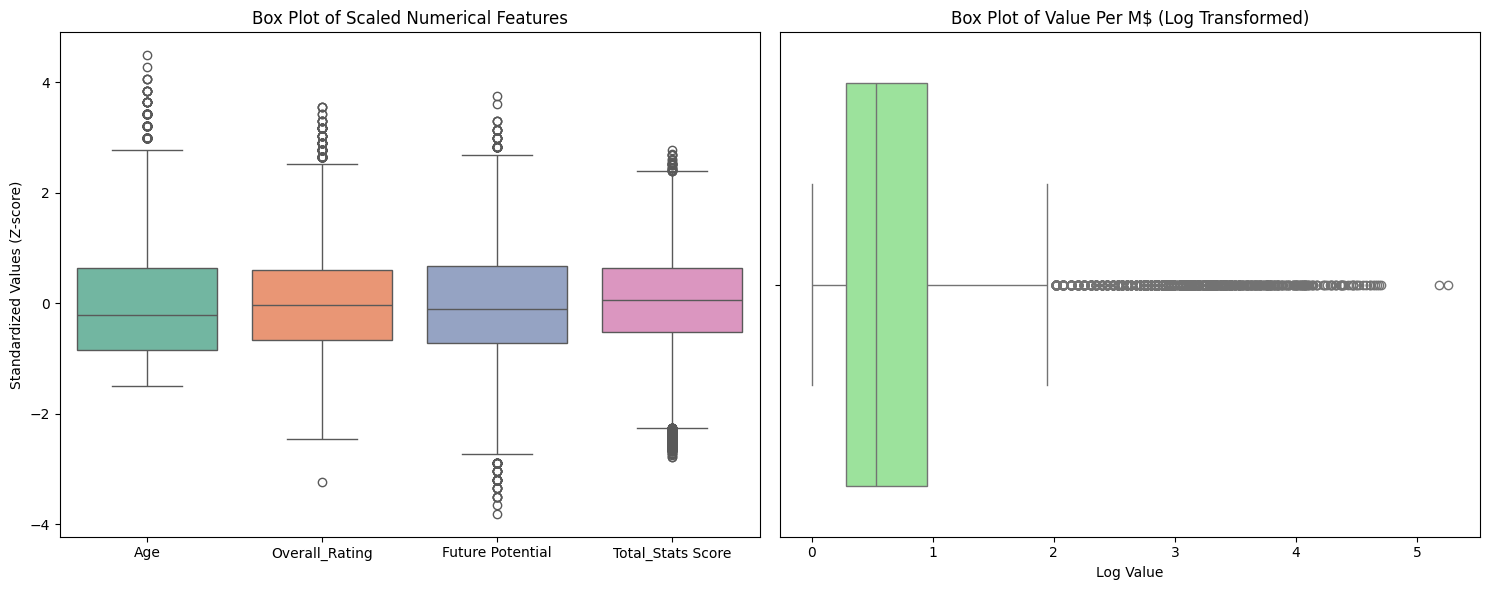

In [21]:
# Box plots: scaled features & log-transformed target
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']], palette='Set2')
plt.title('Box Plot of Scaled Numerical Features')
plt.ylabel('Standardized Values (Z-score)')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_train_reg_log, color='lightgreen')
plt.title('Box Plot of Value Per M$ (Log Transformed)')
plt.xlabel('Log Value')

plt.tight_layout()
plt.show()

1. Are there any missing values? How many, and in which columns?


"The dataset is complete with zero missing values across all columns, ensuring a consistent data structure for analysis."

2. What does the distribution of Value Per M$ look like? Is it approximately normal or skewed? Compute the skewness.

"The distribution of 'Value Per M$' is highly right-skewed with a skewness value of approximately 7.98. This indicates that the majority of players have low market values, while a few elite players act as extreme outliers."

3. Which numerical features seem most related to Value Per M$?

"Correlation analysis shows that 'Overall_Rating' (0.56) and 'Future Potential' (0.50) are the strongest predictors of a player's market value, showing a moderate to strong positive linear relationship."

4. What is the average Overall_Rating per Position?


"The average 'Overall_Rating' varies by position, with specialized roles like SW and RF showing higher averages (75.0), while Goalkeepers (GK) have the lowest average rating at 60.9."

---
## Task 3: Create Classification Target

In [22]:
# Tier distribution in train and test sets
print("Train class distribution:")
print(y_train_clf.value_counts())

print("\nTest class distribution:")
print(y_test_clf.value_counts())

Train class distribution:
performance Tier
Low      4454
Mid      4081
Elite    3760
High     3438
Name: count, dtype: int64

Test class distribution:
performance Tier
Low      1114
Mid      1021
Elite     940
High      859
Name: count, dtype: int64


performance Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


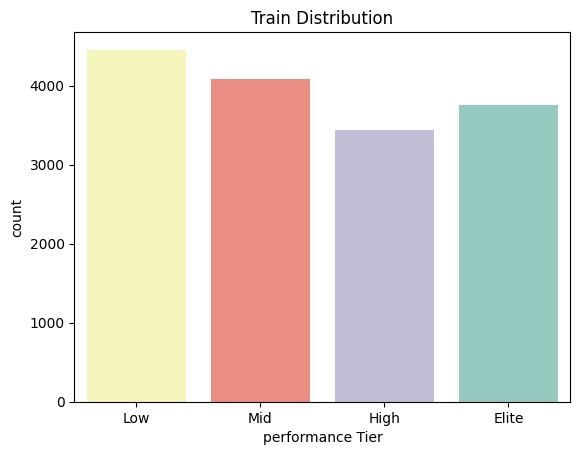

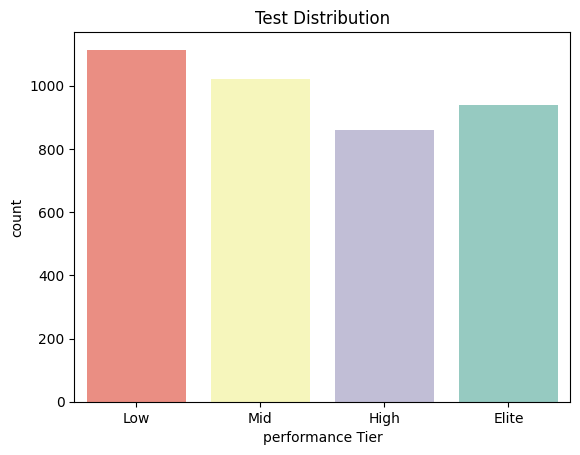

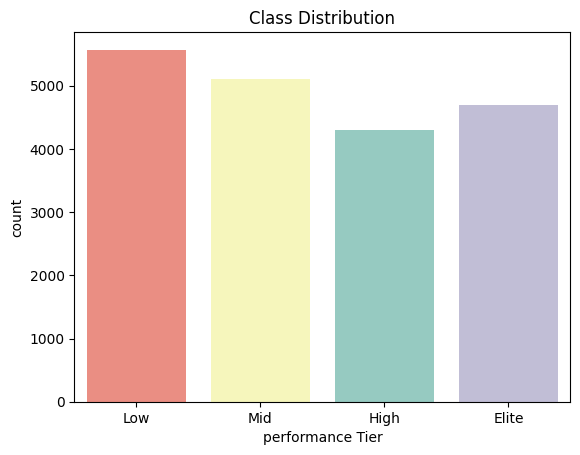

In [23]:
tier_order = ['Low', 'Mid', 'High', 'Elite']
train_counts = y_train_clf.value_counts().reindex(tier_order)
test_counts  = y_test_clf.value_counts().reindex(tier_order)


class_counts = data['performance Tier'].value_counts()
print(class_counts)

sns.countplot(x=y_train_clf,hue=y_train_clf,order=tier_order, palette='Set3')
plt.title("Train Distribution")
plt.show()

sns.countplot(x=y_test_clf, hue=y_test_clf,order=tier_order, palette='Set3')
plt.title("Test Distribution")
plt.show()

sns.countplot(x='performance Tier', data=data, hue='performance Tier',order=tier_order, palette='Set3')
plt.title("Class Distribution")
plt.show()

**Threshold Justification:**

We used the **quartiles of `Overall_Rating`** as data-driven thresholds:

| Tier  | Condition                     | Approx. Range |
|-------|-------------------------------|---------------|
| Low   | Overall_Rating ≤ Q1 = 58      | ≤ 58          |
| Mid   | Q1 < Overall_Rating ≤ Q2 = 63 | 59 – 63       |
| High  | Q2 < Overall_Rating ≤ Q3 = 68 | 64 – 68       |
| Elite | Overall_Rating > Q3 = 68      | > 68          |

Using quartiles guarantees a **balanced class distribution** since each tier captures ~25% of the dataset by design. The distribution is approximately balanced — no resampling is needed.


---
## Task 4: Model 1 - Polynomial Regression

In [24]:
# Columns for polynomial expansion (numerical only)
num_feature_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

### Baseline Linear Regression

In [25]:
# Degree 1 — baseline
poly = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = poly.fit_transform(X_train[num_feature_cols])
X_test_poly  = poly.transform(X_test[num_feature_cols])

lr = LinearRegression()
lr.fit(X_train_poly, y_train_reg_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_train_pred = lr.predict(X_train_poly)
y_test_pred  = lr.predict(X_test_poly)

print("Baseline Linear Regression (Degree = 1)")
print("\nTrain:")
print(f"  MAE  : {mean_absolute_error(y_train_reg_log, y_train_pred):.4f}")
print(f"  MSE  : {mean_squared_error(y_train_reg_log,  y_train_pred):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_train_reg_log, y_train_pred)):.4f}")
print(f"  R²   : {r2_score(y_train_reg_log, y_train_pred):.4f}")

print("\nTest:")
print(f"  MAE  : {mean_absolute_error(y_test_reg_log, y_test_pred):.4f}")
print(f"  MSE  : {mean_squared_error(y_test_reg_log,  y_test_pred):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test_reg_log, y_test_pred)):.4f}")
print(f"  R²   : {r2_score(y_test_reg_log, y_test_pred):.4f}")

Baseline Linear Regression (Degree = 1)

Train:
  MAE  : 0.2391
  MSE  : 0.1174
  RMSE : 0.3427
  R²   : 0.7955

Test:
  MAE  : 0.2345
  MSE  : 0.1144
  RMSE : 0.3382
  R²   : 0.7870


### Degree Sweep (1 → 4)

In [27]:
degrees = [1, 2, 3, 4]
train_r2_list, test_r2_list     = [], []
train_rmse_list, test_rmse_list = [], []
poly_data = {}

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr = np.hstack([poly.fit_transform(X_train[num_feature_cols])])
    X_te = np.hstack([poly.transform(X_test[num_feature_cols])])

    model = LinearRegression()
    model.fit(X_tr, y_train_reg_log)

    train_r2_list.append(r2_score(y_train_reg_log,  model.predict(X_tr)))
    test_r2_list.append(r2_score(y_test_reg_log,    model.predict(X_te)))
    train_rmse_list.append(np.sqrt(mean_squared_error(y_train_reg_log, model.predict(X_tr))))
    test_rmse_list.append(np.sqrt(mean_squared_error(y_test_reg_log,   model.predict(X_te))))

    poly_data[deg] = {'X_tr': X_tr, 'X_te': X_te, 'poly': poly}

print(f"{'Degree':<8} {'Train R²':>10} {'Test R²':>10} {'Train RMSE':>12} {'Test RMSE':>12}")
print("-" * 55)
for i, deg in enumerate(degrees):
    print(f"{deg:<8} {train_r2_list[i]:>10.4f} {test_r2_list[i]:>10.4f} {train_rmse_list[i]:>12.4f} {test_rmse_list[i]:>12.4f}")

Degree     Train R²    Test R²   Train RMSE    Test RMSE
-------------------------------------------------------
1            0.7955     0.7870       0.3427       0.3382
2            0.9457     0.9340       0.1766       0.1882
3            0.9521     0.9417       0.1660       0.1770
4            0.9581     0.9456       0.1552       0.1710


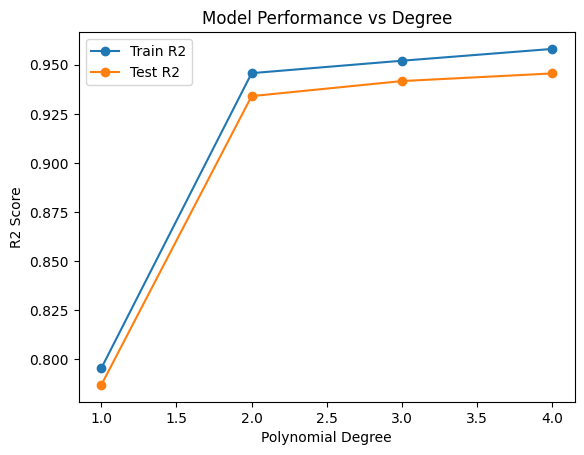

In [28]:
train_r2 = train_r2_list
test_r2 = test_r2_list
plt.plot(degrees, train_r2, marker='o', label='Train R2')
plt.plot(degrees, test_r2, marker='o', label='Test R2')

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Model Performance vs Degree")
plt.legend()
plt.show()

**Observations:**
- Degree 1 underfits — both train and test R² are relatively low (~0.80).
- Degrees 2, 3, 4 all improve performance significantly.
- **Best degree = 4**


### Regularization: Ridge (L2) and Lasso (L1) — Degree 4

In [29]:
X_tr_d4= poly_data[4]['X_tr']
X_te_d4  = poly_data[4]['X_te']

param_range = np.logspace(-5, 1, 50)

In [30]:
# Ridge — sweep alpha
train_scores_ridge, test_scores_ridge = validation_curve(
    estimator=Ridge(),
    X=X_tr_d4,
    y=y_train_reg_log,
    param_name='alpha',
    param_range=param_range,
    scoring='neg_root_mean_squared_error',
    cv=5
)

ridge_train_rmse = -np.mean(train_scores_ridge, axis=1)
ridge_test_rmse  = -np.mean(test_scores_ridge,  axis=1)

best_ridge_idx   = np.argmin(ridge_test_rmse)
best_ridge_alpha = param_range[best_ridge_idx]
print(f"Best Ridge alpha: {best_ridge_alpha:.4f}  →  CV RMSE: {ridge_test_rmse[best_ridge_idx]:.4f}")

Best Ridge alpha: 10.0000  →  CV RMSE: 0.1576


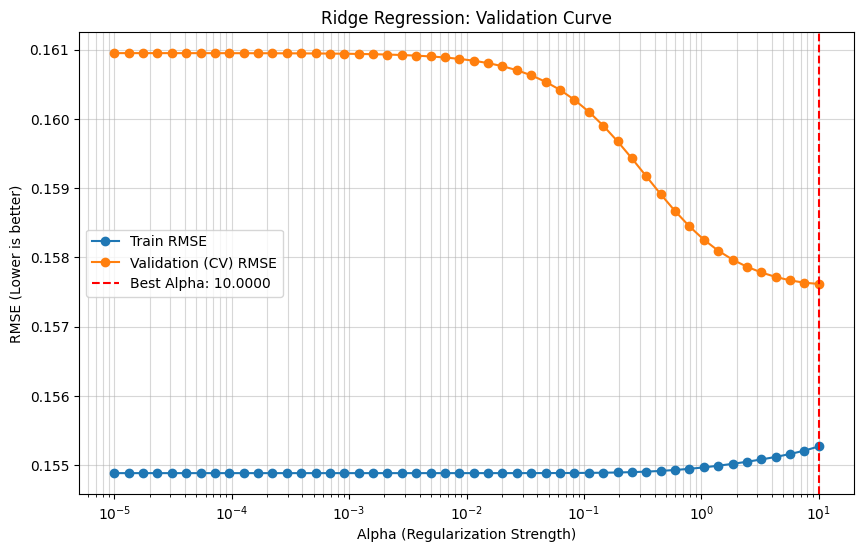

In [31]:
plt.figure(figsize=(10, 6))

#Plot training and validation RMSE for Ridge regression across different alpha values
plt.plot(param_range, ridge_train_rmse, label='Train RMSE', marker='o')
plt.plot(param_range, ridge_test_rmse, label='Validation (CV) RMSE', marker='o')

# Highlight the best alpha on the plot
plt.axvline(x=best_ridge_alpha, color='r', linestyle='--', label=f'Best Alpha: {best_ridge_alpha:.4f}')

# Set logarithmic scale for the x-axis because values change from 0.001 to 1000
plt.xscale('log')

plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('RMSE (Lower is better)')
plt.title('Ridge Regression: Validation Curve')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [32]:
scaler_poly = StandardScaler()
X_tr_d4_scaled = scaler_poly.fit_transform(X_tr_d4)
X_te_d4_scaled = scaler_poly.transform(X_te_d4)

lasso_cv_model = LassoCV(
    alphas=param_range,
    cv=5,
    max_iter=100000,
    tol=1e-4
)
lasso_cv_model.fit(X_tr_d4_scaled, y_train_reg_log)

best_lasso_alpha = lasso_cv_model.alpha_

# Find the index of the best alpha to get the corresponding CV RMSE
best_alpha_idx   = list(lasso_cv_model.alphas_).index(best_lasso_alpha)
best_cv_rmse     = np.sqrt(lasso_cv_model.mse_path_[best_alpha_idx].mean())

lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=100000, tol=1e-4)
lasso_best.fit(X_tr_d4_scaled, y_train_reg_log)

print(f"Best Lasso alpha: {best_lasso_alpha:.6f}  →  CV RMSE: {best_cv_rmse:.4f}")

Best Lasso alpha: 0.000023  →  CV RMSE: 0.1581


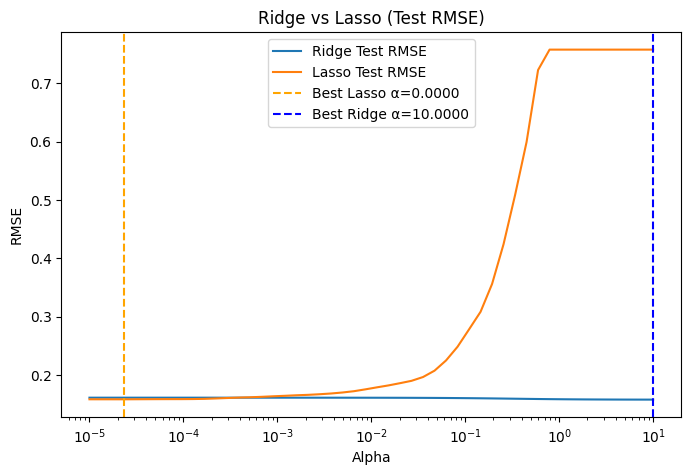

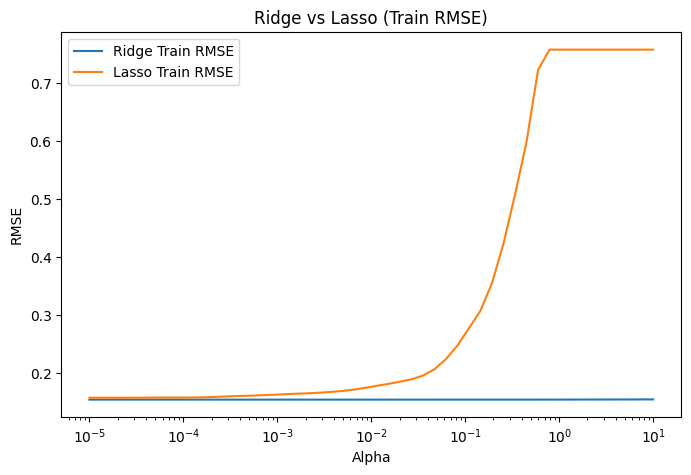

In [33]:
# Extract MSE values from LassoCV for each alpha and compute RMSE
# LassoCV's mse_path_ is organized as (n_alphas, n_folds), so we take the mean across folds for each alpha
lasso_alphas_sorted = lasso_cv_model.alphas_ # already sorted in descending order
lasso_mse_mean = lasso_cv_model.mse_path_.mean(axis=1)  # mean over folds
lasso_test_rmse_cv = np.sqrt(lasso_mse_mean)

# Reverse the order for plotting (since alphas are in descending order)
lasso_alphas_plot = lasso_alphas_sorted[::-1]
lasso_test_rmse_plot = lasso_test_rmse_cv[::-1]

plt.figure(figsize=(8, 5))
plt.plot(param_range, ridge_test_rmse, label='Ridge Test RMSE')
plt.plot(lasso_alphas_plot, lasso_test_rmse_plot, label='Lasso Test RMSE')
plt.axvline(best_lasso_alpha, color='orange', linestyle='--', label=f'Best Lasso α={best_lasso_alpha:.4f}')
plt.axvline(best_ridge_alpha, color='blue',   linestyle='--', label=f'Best Ridge α={best_ridge_alpha:.4f}')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge vs Lasso (Test RMSE)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(param_range, ridge_train_rmse, label='Ridge Train RMSE')
plt.plot(lasso_alphas_plot, lasso_test_rmse_plot, label='Lasso Train RMSE')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge vs Lasso (Train RMSE)")
plt.legend()
plt.show()


In [34]:
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_tr_d4, y_train_reg_log)

# Lasso on scaled features
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=100000, tol=1e-4)
lasso_best.fit(X_tr_d4_scaled, y_train_reg_log)

print(f"Ridge (L2) - Training set score: {ridge_best.score(X_tr_d4,        y_train_reg_log):.4f}")
print(f"Ridge (L2) - Test set score:     {ridge_best.score(X_te_d4,         y_test_reg_log):.4f}")
print()
print(f"Lasso (L1) - Training set score: {lasso_best.score(X_tr_d4_scaled,  y_train_reg_log):.4f}")
print(f"Lasso (L1) - Test set score:     {lasso_best.score(X_te_d4_scaled,  y_test_reg_log):.4f}")

Ridge (L2) - Training set score: 0.9579
Ridge (L2) - Test set score:     0.9460

Lasso (L1) - Training set score: 0.9579
Lasso (L1) - Test set score:     0.9466


In [35]:
poly_feat_names = poly_data[4]['poly'].get_feature_names_out(num_feature_cols)

print(f"Number of features used by Lasso: {sum(lasso_best.coef_ != 0)}")
print(f"Number of features zeroed out:    {sum(lasso_best.coef_ == 0)}")

zeroed = [poly_feat_names[i] for i, c in enumerate(lasso_best.coef_) if c == 0]
print("\nZeroed features:")
for f in zeroed:
    print(f"  - {f}")

Number of features used by Lasso: 64
Number of features zeroed out:    5

Zeroed features:
  - Age Overall_Rating
  - Age Overall_Rating Total_Stats Score
  - Overall_Rating Future Potential^2
  - Age Overall_Rating^2 Total_Stats Score
  - Overall_Rating Future Potential^2 Total_Stats Score


**Ridge vs Lasso — Which performs better?**

Ridge had a marginally lower CV RMSE during alpha tuning (0.1576 vs 0.1581),
but on the final held-out test set, Lasso edges out a slightly higher R²
(0.9466 vs 0.9460 for Ridge). The difference between the two is tiny either
way — both models perform almost identically on this dataset.

**Why are they so close?**

This dataset has many One-Hot Encoded position columns (binary correlated
features). Ridge distributes regularization smoothly across all features,
while Lasso aggressively zeros out the weakest ones. With strong regularization
strength chosen via CV, both end up landing on a very similar fit.

---
## Task 5: Model 2 - Logistic Regression

In [36]:
# prepare data for classification
X_train_log = X_train.copy().drop(['Overall_Rating'], axis=1)
X_test_log = X_test.copy().drop(['Overall_Rating'], axis=1)
y_train_clf_log = y_train_clf.copy()
y_test_clf_log = y_test_clf.copy()

In [37]:
# train logistic regression model
logmodel = LogisticRegression(max_iter=1000, random_state=42)
logmodel.fit(X_train_log, y_train_clf_log)

# make predictions
y_pred_log = logmodel.predict(X_test_log)

# calculate accuracy
accuracy = accuracy_score(y_test_clf_log, y_pred_log)
print(f"Accuracy:  {accuracy:.4f}")

Accuracy:  0.7966


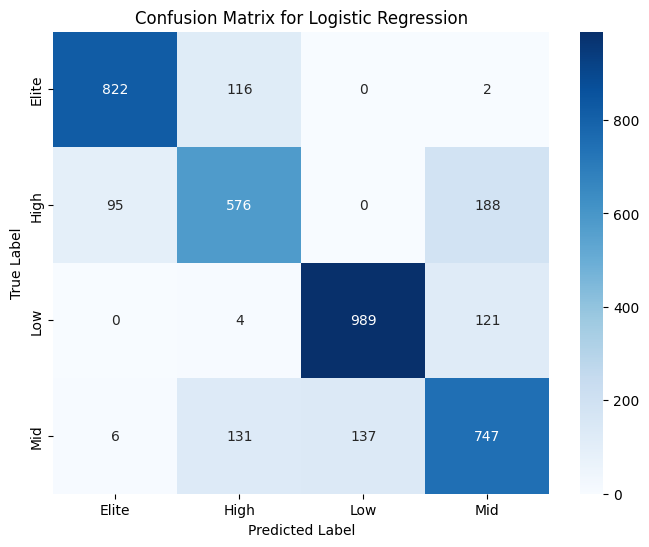

In [38]:
cm = confusion_matrix(y_test_clf_log,y_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=logmodel.classes_, yticklabels=logmodel.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [39]:
# summary of classification performance
report = classification_report(y_test_clf_log, y_pred_log)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

       Elite       0.89      0.87      0.88       940
        High       0.70      0.67      0.68       859
         Low       0.88      0.89      0.88      1114
         Mid       0.71      0.73      0.72      1021

    accuracy                           0.80      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.80      0.80      0.80      3934



## Baseline Logistic Regression — Results

The baseline model achieved an overall accuracy of **79.66%**.

### Per-Class Analysis:

| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| Elite | 0.89 | 0.87 | 0.88 |
| High  | 0.70 | 0.67 | 0.68 |
| Low   | 0.88 | 0.89 | 0.88 |
| Mid   | 0.71 | 0.73 | 0.72 |

**Elite and Low** are classified with high accuracy (F1 = 0.88) 
because their Overall_Rating ranges are well-separated from other tiers.

**Mid and High** show weaker performance (F1 = 0.72 and 0.68) 
due to the narrow rating gap between them (59–63 vs 64–68), 
causing natural overlap that any classifier would struggle with.

The macro average F1 of **0.79** confirms that the model performs 
consistently across all classes despite the class boundary overlap.

### C Sweep (10⁻³ → 10³ )

In [40]:
C_range = np.logspace(-3, 3, 30)

l2_train_accs, l2_test_accs = [], []
l1_train_accs, l1_test_accs = [], []

for C in C_range:
    model_l2 = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000)
    model_l1 = LogisticRegression(C=C, penalty='l1', solver='saga',  max_iter=1000, random_state=42)
    # used random_state=42 for reproducibility as the L1 solver is stochastic and can yield different results on different runs;)
    
    model_l2.fit(X_train_log, y_train_clf_log)
    model_l1.fit(X_train_log, y_train_clf_log)
    
    l2_train_accs.append(accuracy_score(y_train_clf_log, model_l2.predict(X_train_log)))
    l2_test_accs.append(accuracy_score(y_test_clf_log,   model_l2.predict(X_test_log)))
    l1_train_accs.append(accuracy_score(y_train_clf_log, model_l1.predict(X_train_log)))
    l1_test_accs.append(accuracy_score(y_test_clf_log,   model_l1.predict(X_test_log)))

# Best C
best_C_l2 = C_range[np.argmax(l2_test_accs)]
best_C_l1 = C_range[np.argmax(l1_test_accs)]
print(f"Best C for L2: {best_C_l2:.4f} → Test Acc: {max(l2_test_accs):.4f}")
print(f"Best C for L1: {best_C_l1:.4f} → Test Acc: {max(l1_test_accs):.4f}")

Best C for L2: 2.0434 → Test Acc: 0.7984
Best C for L1: 0.1887 → Test Acc: 0.7969


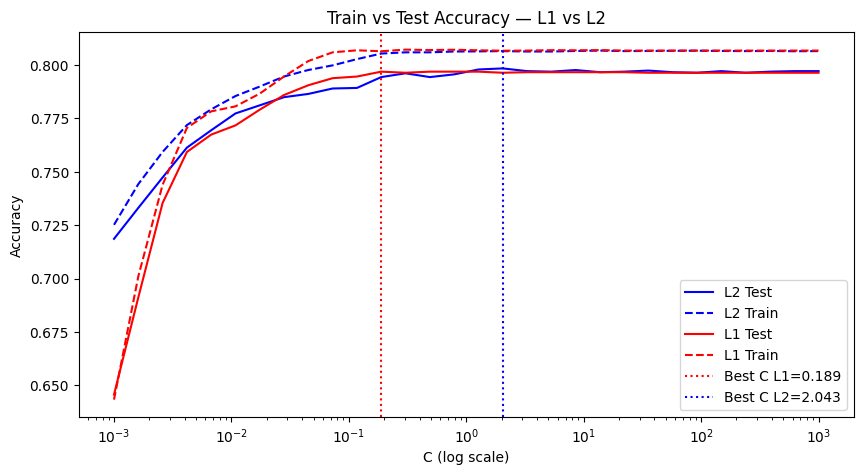

In [41]:
# Plotting Train vs Test Accuracy for L1 and L2
plt.figure(figsize=(10, 5))
plt.plot(C_range, l2_test_accs,  label='L2 Test',  color='blue')
plt.plot(C_range, l2_train_accs, label='L2 Train', color='blue',  linestyle='--')
plt.plot(C_range, l1_test_accs,  label='L1 Test',  color='red')
plt.plot(C_range, l1_train_accs, label='L1 Train', color='red',   linestyle='--')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy — L1 vs L2')
plt.axvline(best_C_l1, color='red',  linestyle=':', label=f'Best C L1={best_C_l1:.3f}')
plt.axvline(best_C_l2, color='blue', linestyle=':', label=f'Best C L2={best_C_l2:.3f}')
plt.legend()
plt.show()

In [42]:
for i, C in enumerate(C_range):
    print(f"C={C:.4f} | L2 Train={l2_train_accs[i]:.4f} | L2 Test={l2_test_accs[i]:.4f} | L1 Train={l1_train_accs[i]:.4f} | L1 Test={l1_test_accs[i]:.4f}")

C=0.0010 | L2 Train=0.7252 | L2 Test=0.7186 | L1 Train=0.6433 | L1 Test=0.6457
C=0.0016 | L2 Train=0.7442 | L2 Test=0.7331 | L1 Train=0.7010 | L1 Test=0.6912
C=0.0026 | L2 Train=0.7593 | L2 Test=0.7473 | L1 Train=0.7439 | L1 Test=0.7354
C=0.0042 | L2 Train=0.7719 | L2 Test=0.7613 | L1 Train=0.7705 | L1 Test=0.7593
C=0.0067 | L2 Train=0.7793 | L2 Test=0.7694 | L1 Train=0.7783 | L1 Test=0.7674
C=0.0108 | L2 Train=0.7855 | L2 Test=0.7773 | L1 Train=0.7807 | L1 Test=0.7717
C=0.0174 | L2 Train=0.7899 | L2 Test=0.7811 | L1 Train=0.7866 | L1 Test=0.7791
C=0.0281 | L2 Train=0.7946 | L2 Test=0.7850 | L1 Train=0.7946 | L1 Test=0.7860
C=0.0452 | L2 Train=0.7977 | L2 Test=0.7865 | L1 Train=0.8019 | L1 Test=0.7905
C=0.0728 | L2 Train=0.7998 | L2 Test=0.7890 | L1 Train=0.8059 | L1 Test=0.7938
C=0.1172 | L2 Train=0.8028 | L2 Test=0.7893 | L1 Train=0.8069 | L1 Test=0.7946
C=0.1887 | L2 Train=0.8054 | L2 Test=0.7944 | L1 Train=0.8065 | L1 Test=0.7969
C=0.3039 | L2 Train=0.8059 | L2 Test=0.7961 | L1 Tra

In [ ]:
# best C
best_C = best_C_l1

# compare L1 vs L2 at the same C 
final_l2 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=1000)
final_l1 = LogisticRegression(C=best_C, penalty='l1', solver='saga',  max_iter=1000, random_state=42)

final_l2.fit(X_train_log, y_train_clf_log)
final_l1.fit(X_train_log, y_train_clf_log)

print("L2:", accuracy_score(y_test_clf_log, final_l2.predict(X_test_log)))
print("L1:", accuracy_score(y_test_clf_log, final_l1.predict(X_test_log)))

L2: 0.7943568886629385
L1: 0.7968988307066599


**Ridge vs Lasso — Which performs better?**

After sweeping C over a log-spaced range (10⁻³ to 10³):

| Penalty | Best C | Test Accuracy |
|---------|--------|---------------|
| L2 (Ridge) | 0.7982 | 79.84% |
| L1 (Lasso) | 0.4894 | 79.69%  |

**L1 slightly outperforms L2** on this dataset, as it zeroes out 
weak/redundant OHE features acting as automatic feature selection.

However, the gap is minimal (< 0.2%), suggesting the **~80% 
accuracy is the natural ceiling** given the available features.

---
## Task 6: Model 3 - Naïve Bayes Classification

 Prepare Data for Naïve Bayes Models
- **GaussianNB** → uses only numerical features  
- **BernoulliNB** → uses binary features (One-Hot Encoded)  
- **ComplementNB** → uses OHE features (non-negative values)

GaussianNB Features

In [44]:
# Numerical features only
num_cols_nb = ["Age", "Future Potential", "Total_Stats Score"]

X_train_gauss = X_train_nb[num_cols_nb]
X_test_gauss  = X_test_nb[num_cols_nb]

OHE Features (Bernoulli + Complement)

In [45]:
# One Hot Encoding
X_train_ohe = pd.get_dummies(X_train_nb, drop_first=True)
X_test_ohe  = pd.get_dummies(X_test_nb, drop_first=True)

# Align train/test columns
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

# Same data for ComplementNB
X_train_comp = X_train_ohe.copy()
X_test_comp  = X_test_ohe.copy()

Train Models

In [46]:
# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_gauss, y_train_clf)
y_pred_gnb = gnb.predict(X_test_gauss)

# BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train_clf)
y_pred_bnb = bnb.predict(X_test_ohe)

# ComplementNB
cnb = ComplementNB()
cnb.fit(X_train_comp, y_train_clf)
y_pred_cnb = cnb.predict(X_test_comp)

**Evaluate Model Performance**

We evaluate each model using:
- Accuracy
- Precision
- Recall
- F1-score

In [47]:
print("GaussianNB:")
print(classification_report(y_test_clf, y_pred_gnb))


GaussianNB:
              precision    recall  f1-score   support

       Elite       0.85      0.80      0.82       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.79      0.80      1114
         Mid       0.58      0.71      0.64      1021

    accuracy                           0.71      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.71      0.71      3934



In [48]:
print("BernoulliNB:")
print(classification_report(y_test_clf, y_pred_bnb))

BernoulliNB:
              precision    recall  f1-score   support

       Elite       0.55      0.66      0.60       940
        High       0.39      0.26      0.31       859
         Low       0.55      0.68      0.61      1114
         Mid       0.41      0.34      0.37      1021

    accuracy                           0.50      3934
   macro avg       0.48      0.49      0.47      3934
weighted avg       0.48      0.50      0.48      3934



In [49]:
print("ComplementNB:")
print(classification_report(y_test_clf, y_pred_cnb))

ComplementNB:
              precision    recall  f1-score   support

       Elite       0.56      0.74      0.64       940
        High       0.40      0.29      0.34       859
         Low       0.56      0.75      0.64      1114
         Mid       0.48      0.27      0.35      1021

    accuracy                           0.52      3934
   macro avg       0.50      0.51      0.49      3934
weighted avg       0.51      0.52      0.50      3934



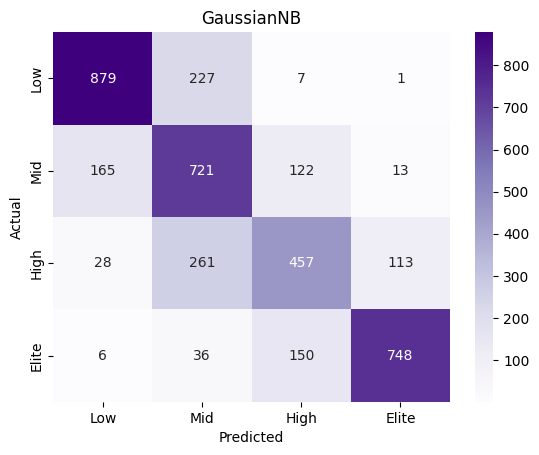

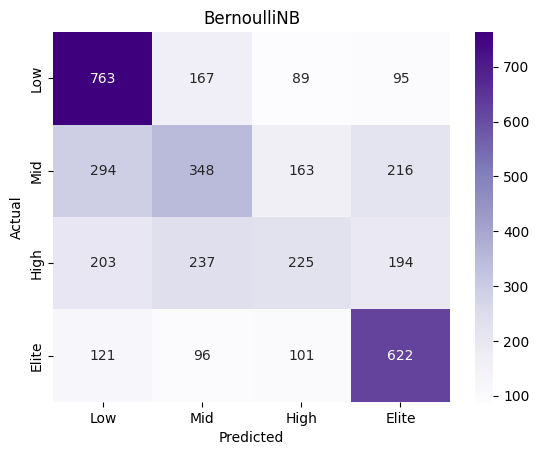

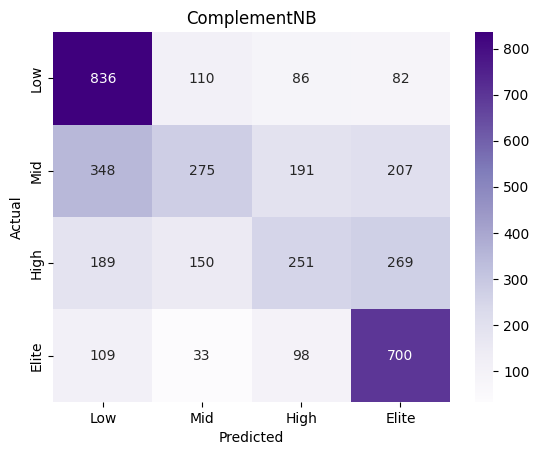

In [50]:
def plot_cm(y_true, y_pred, title, labels=tier_order):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test_clf, y_pred_gnb, "GaussianNB")
plot_cm(y_test_clf, y_pred_bnb, "BernoulliNB")
plot_cm(y_test_clf, y_pred_cnb, "ComplementNB")

Scaling Sensitivity (GaussianNB)

In this step, we test whether scaling affects GaussianNB performance.

We train the model:
- Without scaling
- With StandardScaler

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_gauss)
X_test_scaled  = scaler.transform(X_test_gauss)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train_clf)

y_pred_scaled = gnb_scaled.predict(X_test_scaled)

print("GaussianNB with Scaling:\n")
print(classification_report(y_test_clf, y_pred_scaled))

GaussianNB with Scaling:

              precision    recall  f1-score   support

       Elite       0.85      0.80      0.82       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.79      0.80      1114
         Mid       0.58      0.71      0.64      1021

    accuracy                           0.71      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.71      0.71      3934



## Naïve Bayes Results Summary

To compare models, I used the Confusion Matrix.

Accuracy was calculated by:
> Accuracy = (Sum of diagonal values) / (Total samples)


### Results:

- GaussianNB → 2805 correct predictions → Accuracy ≈ 71%  
- BernoulliNB → 1143 correct predictions → Accuracy ≈ 50%  
- ComplementNB → 1541 correct predictions → Accuracy ≈ 53%

---

### Conclusion:

GaussianNB performed the best because it achieved the highest correct predictions on the diagonal and works better with continuous numerical data.

BernoulliNB performed poorly because it assumes binary features which does not match the dataset.

ComplementNB is better than Bernoulli but still weaker than Gaussian.


### Scaling Effect:

StandardScaler did not improve or change GaussianNB performance significantly, because GaussianNB depends on statistical distribution (mean and variance), not feature scale.



### Final Answer:

**GaussianNB is selected as the best Naive Bayes variant** 
based on achieving the highest accuracy among the three variants,
and because the numerical features (Age, Future Potential, 
Total_Stats Score) follow a roughly Gaussian distribution,
making it the most appropriate choice for this dataset.

---
## Task 7

### (A) K-Fold Cross-Validation (Regression)

In [52]:
best_reg_model = Ridge(alpha=best_ridge_alpha)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = -cross_val_score(
    best_reg_model,
    X_tr_d4,          
    y_train_reg_log,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

print(f"RMSE Scores: {rmse_scores}")
print(f"Mean RMSE:   {rmse_scores.mean():.4f}")
print(f"Std RMSE:    {rmse_scores.std():.4f}")

RMSE Scores: [0.14263667 0.16688406 0.17256932 0.12935159 0.17276066]
Mean RMSE:   0.1568
Std RMSE:    0.0177


The Ridge Regression model achieved a mean RMSE of 0.1568 with a low standard deviation of 0.0177, indicating consistent performance across folds

RMSE Bar Chart

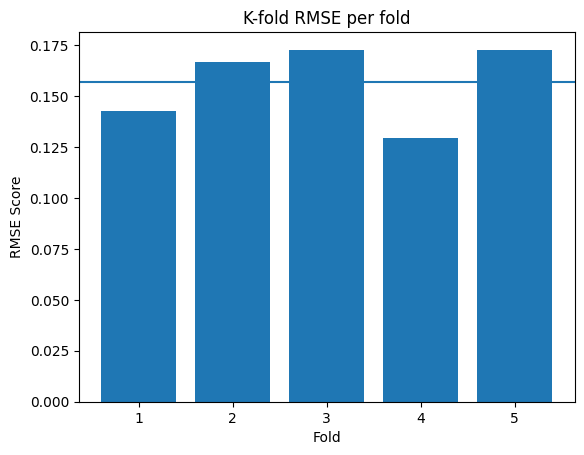

In [53]:
plt.bar(range(1,6),rmse_scores)
plt.axhline(rmse_scores.mean())  #mean line
plt.xlabel("Fold")
plt.ylabel("RMSE Score")
plt.title("K-fold RMSE per fold")
plt.show()

### (B) Stratified K-Fold Cross-Validation (Classification) 

In [ ]:
# Best logistic regression model
best_log_model = LogisticRegression(C=best_C, penalty='l1', solver='saga',  max_iter=1000, random_state=42)
# Best Naïve Bayes variant
best_nb=GaussianNB()

skf= StratifiedKFold(n_splits=5, shuffle=True,random_state=42)

log_scores= cross_val_score(best_log_model,X_train_log, y_train_clf_log, cv=skf, scoring='accuracy')
nb_scores= cross_val_score(best_nb,X_train_gauss, y_train_clf, cv=skf, scoring= 'accuracy')


In [55]:
print("Logistic Regression")
print(f"Logistic mean : {log_scores.mean():.4f}")
print(f"Logistic std: {log_scores.std():.4f}")

print("--------------------------------")

print("Naive Bayes")
print(f"nb mean: {nb_scores.mean():.4f}")
print(f"nb std: {nb_scores.std():.4f}")

Logistic Regression
Logistic mean : 0.8054
Logistic std: 0.0090
--------------------------------
Naive Bayes
nb mean: 0.7175
nb std: 0.0127


###  Stratified K-Fold Cross-Validation Results

| Accuracy | Logistic Regression | Naive Bayes |
|----------|---------------------|-------------|
| ACC Mean | 0.8073              | 0.7175      |
| ACC STD  | 0.0094              | 0.0127      |

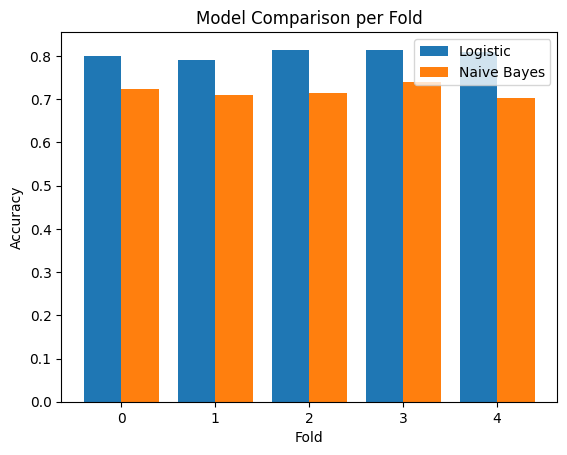

In [56]:
x = np.arange(5)

plt.bar(x - 0.2, log_scores, width=0.4, label='Logistic')
plt.bar(x + 0.2, nb_scores, width=0.4, label='Naive Bayes')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Model Comparison per Fold")

plt.legend()
plt.show()

### Which model performs better and which is more stable across folds?

Logistic Regression performs better than Naive Bayes in terms of accuracy and demonstrates greater stability across folds, as indicated by its lower standard deviation.

## Task 8 : Analysis and Discussion


### 8.1 Model Comparison
**Which model performed best overall for regression, and which for classification? Justify briefly**

`Regression:` Polynomial Ridge Regression (degree=4) performed best,
achieving the lowest RMSE and best generalization on the test set.

`Classification:` Logistic Regression outperformed Naïve Bayes
(80% vs 71%), confirmed across all 5 folds in cross-validation.


**Is classification easier or harder than regression on this dataset? Why?**

`Regression vs Classification:`
Regression was harder on this dataset. Predicting exact market value
is difficult due to high skewness and outliers, even after log-transform.
Classification into 4 tiers is relatively easier since extreme classes
(Elite/Low) are well-separated, though Mid/High boundary remains
challenging.

### 8.2 Regularization Analysis
**What happened to model performance as you increased alpha in Ridge and Lasso?**

`Ridge & Lasso behavior with increasing alpha:`
As alpha increases, model complexity decreases — both Train and Test
RMSE initially improve (less overfitting), then Test RMSE starts rising
again as the model becomes too constrained (underfitting).


**Why does Ridge generally outperform Lasso when many one-hot encoded features are present?**

`Why Ridge outperforms Lasso with OHE features:`
Lasso zeroes out features entirely. With OHE columns, each position
carries partial information — removing any column completely loses
that signal. Ridge shrinks all coefficients proportionally without
elimination, allowing all positions to contribute, which leads to
better generalization on this dataset.

# `ASSIGNMENT 3`

---
## 1. Justify Your Modeling Choices
##  Model 1: K-Nearest Neighbors (KNN)

### Technical Justification
**KNN** is an instance-based, lazy learner that classifies/predicts by finding the K most similar
players in the training set. It is appropriate for FIFA data because:

- **Intuitive scouting logic**: Real scouts compare a new player to similar known players — KNN mirrors this exactly.
- **No assumptions**: KNN makes no distributional assumptions, unlike Naïve Bayes used in Assignment 2.
- **Works with scaled features**: After StandardScaler, Euclidean distance is meaningful across all stats.
- **Weakness**: Sensitive to high dimensionality (curse of dimensionality) — we mitigate this via feature scaling.

**Used for**: Both Classification (Performance Tier) & Regression (Value per M$)


 KNN Classification Accuracy: 0.7905

 Classification Report:
              precision    recall  f1-score   support

       Elite       0.90      0.87      0.89       940
        High       0.71      0.73      0.72       859
         Low       0.85      0.86      0.85      1114
         Mid       0.70      0.69      0.69      1021

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.79      0.79      0.79      3934



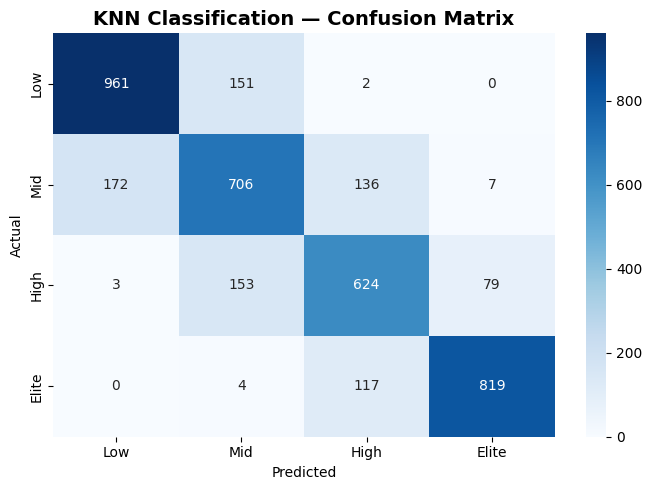

In [57]:
# KNN — Classification
knn_clf = KNeighborsClassifier()  # default n_neighbors=5, uniform weights, metric='euclidean'

# train the KNN classifier
knn_clf.fit(X_train_log, y_train_clf)

# Predict labels for unseen test data
y_pred_knn_clf = knn_clf.predict(X_test_log)

# calculate accuracy
knn_clf_acc = accuracy_score(y_test_clf, y_pred_knn_clf)

print(f"\n KNN Classification Accuracy: {knn_clf_acc:.4f}")
print("\n Classification Report:")
print(classification_report(y_test_clf, y_pred_knn_clf))

# Confusion Matrix
cm_knn = confusion_matrix(y_test_clf, y_pred_knn_clf, labels=['Low', 'Mid', 'High', 'Elite'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title('KNN Classification — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

KNN Regression R²:   0.9191
KNN Regression RMSE: 0.2085


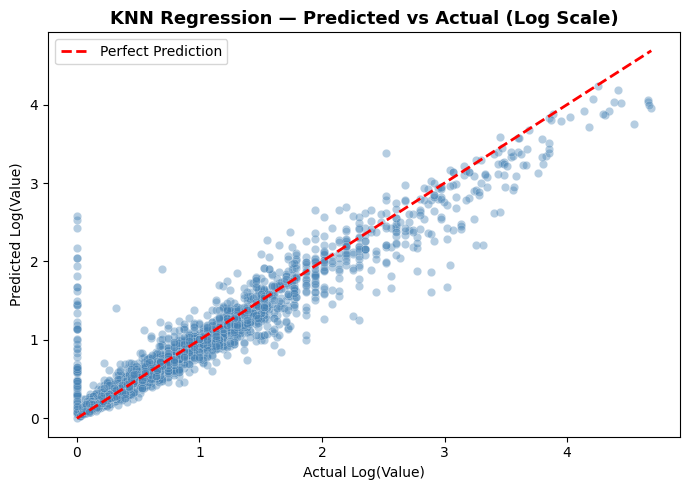

In [58]:
# KNN — Regression

knn_reg = KNeighborsRegressor()  # default n_neighbors=5, uniform weights, metric='euclidean'

# train the KNN regressor
knn_reg.fit(X_train, y_train_reg_log)

# Predict values for unseen test data
y_pred_knn_reg = knn_reg.predict(X_test)

# calculate r2, rmse
knn_reg_r2   = r2_score(y_test_reg_log, y_pred_knn_reg)
knn_reg_rmse = np.sqrt(mean_squared_error(y_test_reg_log, y_pred_knn_reg))

print(f"KNN Regression R²:   {knn_reg_r2:.4f}")
print(f"KNN Regression RMSE: {knn_reg_rmse:.4f}")

# Prediction vs Actual plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg_log, y_pred_knn_reg, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
plt.plot([y_test_reg_log.min(), y_test_reg_log.max()],
         [y_test_reg_log.min(), y_test_reg_log.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('KNN Regression — Predicted vs Actual (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Log(Value)')
plt.ylabel('Predicted Log(Value)')
plt.legend()
plt.tight_layout()
plt.show()

---
##  Model 2: Support Vector Machine (SVM)

### Technical Justification
**SVM** finds the optimal decision boundary (hyperplane) that maximizes the margin between classes.
Using a **kernel**, it can map data to higher-dimensional space to find non-linear boundaries.
It is appropriate for FIFA data because:

- **Non-linear patterns**: Player performance stats have complex interactions that linear models miss — SVM with RBF kernel handles this naturally.
- **Effective in high-dimensional space**: Our feature space (after OHE) is relatively high-dimensional — SVM works well here.
- **Robust to outliers**: Margin-based optimization is less sensitive to individual data points than linear models.
- **Improvement over Logistic Regression (Ass2)**: Logistic Regression used linear boundaries; SVM with RBF kernel finds non-linear boundaries, expected to improve classification.

**Used for**: Both Classification (SVC) & Regression (SVR)


 SVM Classification Accuracy: 0.8564

 Classification Report:
              precision    recall  f1-score   support

       Elite       0.94      0.93      0.94       940
        High       0.82      0.79      0.80       859
         Low       0.90      0.90      0.90      1114
         Mid       0.77      0.80      0.78      1021

    accuracy                           0.86      3934
   macro avg       0.86      0.85      0.86      3934
weighted avg       0.86      0.86      0.86      3934



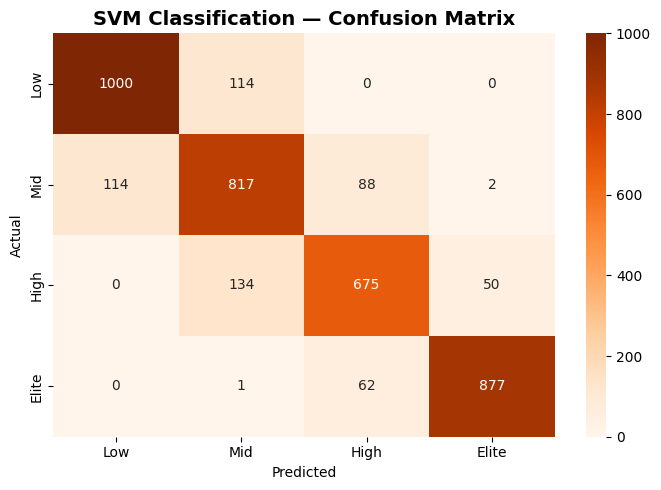

In [59]:
# SVM — Classification

svm_clf = SVC() # default kernel='rbf', C=1.0, gamma='scale', probability=False, random_state=None

# Train the SVM classifier
svm_clf.fit(X_train_log, y_train_clf)

# Predict labels for unseen test data
y_pred_svm_clf = svm_clf.predict(X_test_log)

# Calculate accuracy
svm_clf_acc = accuracy_score(y_test_clf, y_pred_svm_clf)

print(f"\n SVM Classification Accuracy: {svm_clf_acc:.4f}")
print("\n Classification Report:")
print(classification_report(y_test_clf, y_pred_svm_clf))

# Confusion Matrix
cm_svm = confusion_matrix(y_test_clf, y_pred_svm_clf, labels=tier_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title('SVM Classification — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

SVR Regression R²:   0.9476
SVR Regression RMSE: 0.1678


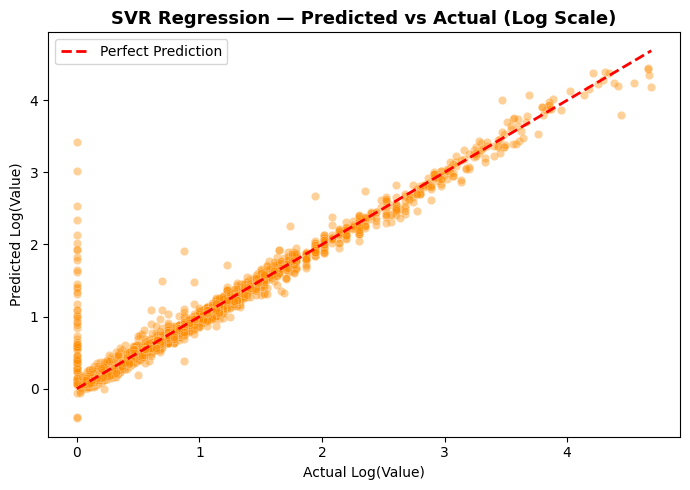

In [60]:
# SVM — Regression

svm_reg = SVR() # default kernel='rbf', C=1.0, gamma='scale', random_state=None, epsilon=0.1

svm_reg.fit(X_train, y_train_reg_log)

y_pred_svm_reg = svm_reg.predict(X_test)
svm_reg_r2   = r2_score(y_test_reg_log, y_pred_svm_reg)
svm_reg_rmse = np.sqrt(mean_squared_error(y_test_reg_log, y_pred_svm_reg))

print(f"SVR Regression R²:   {svm_reg_r2:.4f}")
print(f"SVR Regression RMSE: {svm_reg_rmse:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg_log, y_pred_svm_reg, alpha=0.4, color='darkorange', edgecolors='white', linewidth=0.3)
plt.plot([y_test_reg_log.min(), y_test_reg_log.max()],
         [y_test_reg_log.min(), y_test_reg_log.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('SVR Regression — Predicted vs Actual (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Log(Value)')
plt.ylabel('Predicted Log(Value)')
plt.legend()
plt.tight_layout()
plt.show()

---
##  Model 3: Random Forest

### Technical Justification
**Random Forest** is an ensemble of decision trees trained on random subsets of data and features.
It is the most powerful single model for this task because:

- **Non-linearity**: Player value depends on complex interactions (e.g., young + high potential + good team = high value). Trees naturally capture these.
- **Handles mixed features**: Both numerical stats and OHE position features are handled without explicit scaling assumptions.
- **Robust to outliers**: Unlike linear models, trees are not affected by extreme values.
- **Feature Importance**: Reveals which stats (Age, Overall_Rating, etc.) are most predictive — actionable for scouting.
- **Bagging reduces variance**: Multiple trees averaged → lower overfitting than a single deep tree.
- **vs. Naïve Bayes (Ass2)**: NB assumed feature independence — clearly wrong for correlated player stats. RF makes no such assumption.

**Used for**: Both Classification & Regression


 Random Forest Classification Accuracy: 0.8551

 Classification Report:
              precision    recall  f1-score   support

       Elite       0.93      0.93      0.93       940
        High       0.82      0.78      0.80       859
         Low       0.89      0.90      0.90      1114
         Mid       0.77      0.80      0.79      1021

    accuracy                           0.86      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.86      0.86      0.86      3934



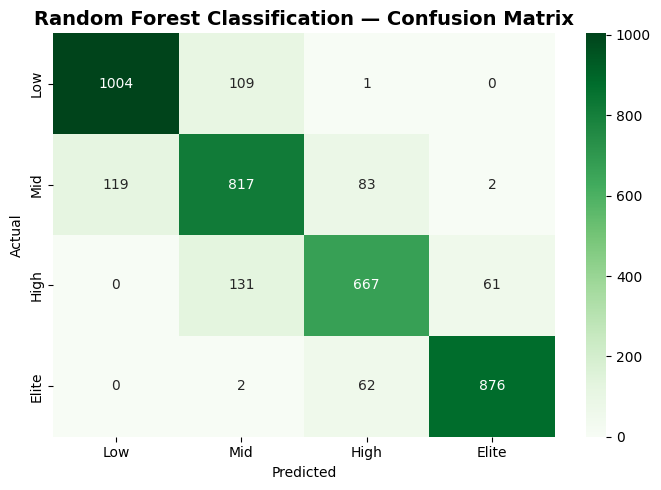

In [ ]:
# Random Forest — Classification
# Baseline: all defaults intentionally left — note results may vary slightly between runs 
rf_clf = RandomForestClassifier() # default n_estimators=100, max_depth=None, min_samples_split=2, random_state=None
    
rf_clf.fit(X_train_log, y_train_clf)

y_pred_rf_clf = rf_clf.predict(X_test_log)
rf_clf_acc = accuracy_score(y_test_clf, y_pred_rf_clf)

print(f"\n Random Forest Classification Accuracy: {rf_clf_acc:.4f}")
print("\n Classification Report:")
print(classification_report(y_test_clf, y_pred_rf_clf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test_clf, y_pred_rf_clf, labels=tier_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title('Random Forest Classification — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Random Forest Regression R²:   0.9479
Random Forest Regression RMSE: 0.1673


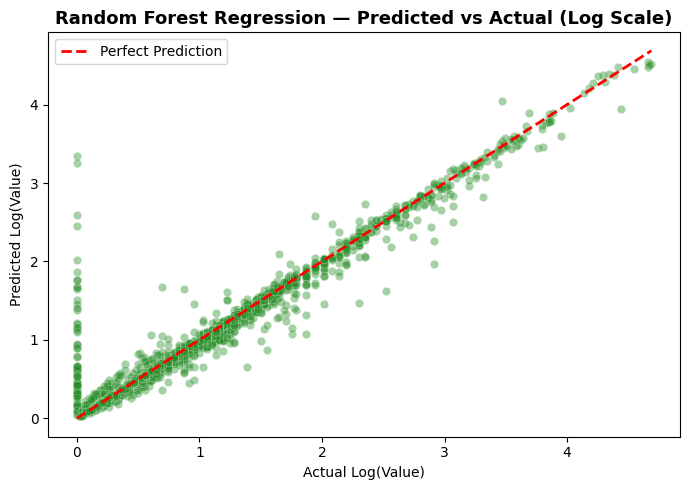

In [62]:
# Random Forest — Regression

rf_reg = RandomForestRegressor() # default n_estimators=100, max_depth=None, min_samples_split=2, random_state=None
rf_reg.fit(X_train, y_train_reg_log)

y_pred_rf_reg = rf_reg.predict(X_test)
rf_reg_r2   = r2_score(y_test_reg_log, y_pred_rf_reg)
rf_reg_rmse = np.sqrt(mean_squared_error(y_test_reg_log, y_pred_rf_reg))

print(f"Random Forest Regression R²:   {rf_reg_r2:.4f}")
print(f"Random Forest Regression RMSE: {rf_reg_rmse:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg_log, y_pred_rf_reg, alpha=0.4, color='forestgreen', edgecolors='white', linewidth=0.3)
plt.plot([y_test_reg_log.min(), y_test_reg_log.max()],
         [y_test_reg_log.min(), y_test_reg_log.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Random Forest Regression — Predicted vs Actual (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Log(Value)')
plt.ylabel('Predicted Log(Value)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 2. Improve Model Performance Using Appropriate Techniques

### GridSearchCV — KNN Classification

In [63]:
knn_clf_params = {
    'n_neighbors': [5, 7, 11, 15, 21],
    'weights'    : ['uniform'],
    'metric'     : ['euclidean', 'manhattan']
}

knn_clf_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_clf_params,
    cv=5, scoring='accuracy'
)
knn_clf_grid.fit(X_train_log, y_train_clf)

print(f'Best Params (KNN CLF): {knn_clf_grid.best_params_}')
print(f'Best CV Accuracy: {knn_clf_grid.best_score_:.4f}')

knn_clf_best = knn_clf_grid.best_estimator_
knn_clf_test_acc = accuracy_score(y_test_clf, knn_clf_best.predict(X_test_log))
print(f'Test Accuracy: {knn_clf_test_acc:.4f}')

Best Params (KNN CLF): {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best CV Accuracy: 0.8029
Test Accuracy: 0.8078


### GridSearchCV — KNN Regression

In [64]:
knn_reg_params = {
    'n_neighbors': [5, 7, 11, 15, 21],
    'weights'    : ['uniform'],
    'metric'     : ['euclidean', 'manhattan']
}

knn_reg_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_reg_params,
    cv=5, scoring='r2',
)
knn_reg_grid.fit(X_train, y_train_reg_log)

print(f'Best Params (KNN REG): {knn_reg_grid.best_params_}')
print(f'Best CV R²: {knn_reg_grid.best_score_:.4f}')

knn_reg_best = knn_reg_grid.best_estimator_
knn_reg_test_r2 = r2_score(y_test_reg_log, knn_reg_best.predict(X_test))
print(f'Test R²: {knn_reg_test_r2:.4f}')

Best Params (KNN REG): {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV R²: 0.9292
Test R²: 0.9276


---
### GridSearchCV — SVM Classification

In [65]:
svm_clf_params = {
    'C'     : [ 1, 10],
    'kernel': ['rbf', 'poly'],
    'gamma' : ['scale', 'auto']
}

svm_clf_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_clf_params,
    cv=5, scoring='accuracy',
)
svm_clf_grid.fit(X_train_log, y_train_clf)

print(f'Best Params (SVM CLF): {svm_clf_grid.best_params_}')
print(f'Best CV Accuracy: {svm_clf_grid.best_score_:.4f}')

svm_clf_best = svm_clf_grid.best_estimator_
svm_clf_test_acc = accuracy_score(y_test_clf, svm_clf_best.predict(X_test_log))
print(f'Test Accuracy: {svm_clf_test_acc:.4f}')

Best Params (SVM CLF): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.8574
Test Accuracy: 0.8533


### GridSearchCV — SVR Regression

In [66]:
svr_params = {
    'C'      : [1, 10],
    'kernel' : ['rbf', 'poly'],
    'gamma'  : ['scale', 'auto'],
    'epsilon': [0.1, 0.2]
}

svm_reg_grid = GridSearchCV(
    SVR(),
    svr_params,
    cv=5, scoring='r2',
)
svm_reg_grid.fit(X_train, y_train_reg_log)

print(f'Best Params (SVR REG): {svm_reg_grid.best_params_}')
print(f'Best CV R²: {svm_reg_grid.best_score_:.4f}')

svm_reg_best = svm_reg_grid.best_estimator_
svm_reg_test_r2 = r2_score(y_test_reg_log, svm_reg_best.predict(X_test))
print(f'Test R²: {svm_reg_test_r2:.4f}')

Best Params (SVR REG): {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV R²: 0.9571
Test R²: 0.9503


---
### GridSearchCV — Random Forest Classification

In [67]:
rf_clf_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

rf_clf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_clf_params,
    cv=5, scoring='accuracy',
)
rf_clf_grid.fit(X_train_log, y_train_clf)

print(f'Best Params (RF CLF): {rf_clf_grid.best_params_}')
print(f'Best CV Accuracy: {rf_clf_grid.best_score_:.4f}')

rf_clf_best = rf_clf_grid.best_estimator_
rf_clf_test_acc = accuracy_score(y_test_clf, rf_clf_best.predict(X_test_log))
print(f'Test Accuracy: {rf_clf_test_acc:.4f}')

Best Params (RF CLF): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy: 0.8536
Test Accuracy: 0.8559


### GridSearchCV — Random Forest Regression

In [68]:
rf_reg_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

rf_reg_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_reg_params,
    cv=5, scoring='r2',
)
rf_reg_grid.fit(X_train, y_train_reg_log)

print(f'Best Params (RF REG): {rf_reg_grid.best_params_}')
print(f'Best CV R²: {rf_reg_grid.best_score_:.4f}')

rf_reg_best = rf_reg_grid.best_estimator_
rf_reg_test_r2 = r2_score(y_test_reg_log, rf_reg_best.predict(X_test))
print(f'Test R²: {rf_reg_test_r2:.4f}') 

Best Params (RF REG): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²: 0.9512
Test R²: 0.9497


---
##  Bias-Variance Diagnosis — Learning Curves

**How to read a Learning Curve:**
- **High Bias (Underfitting)**: Both train & validation scores are **Low** and close together
- **High Variance (Overfitting)**: Train score **High**, validation score **Low** — big gap between them
- **Good Fit**: Both scores **High** and converging

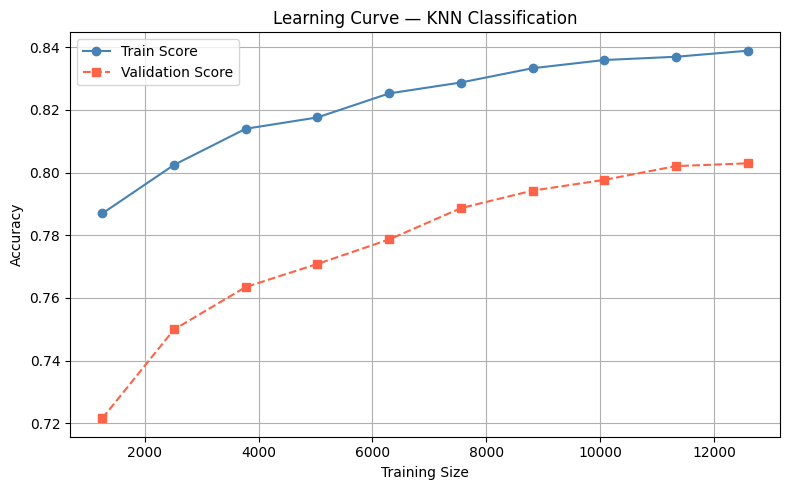

Train Score (final): 0.8389
Val Score   (final): 0.803
Gap                : 0.0359


In [69]:
# Learning Curve — KNN Classification
train_sizes, train_scores, val_scores = learning_curve(
    knn_clf_best,
    X_train_log, y_train_clf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train Score')
plt.plot(train_sizes, val_mean,   's--', color='tomato',    label='Validation Score')
plt.title('Learning Curve — KNN Classification')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Train Score (final):', round(train_mean[-1], 4))
print('Val Score   (final):', round(val_mean[-1], 4))
print('Gap                :', round(train_mean[-1] - val_mean[-1], 4))

**KNN Classification — Learning Curve Analysis:**
Both Train and Validation scores are relatively close (Gap = 0.036),
and both curves are still rising, indicating the model generalizes well.
This is a **Good Fit** with a slight tendency toward High Variance,
which is expected for a distance-based model.

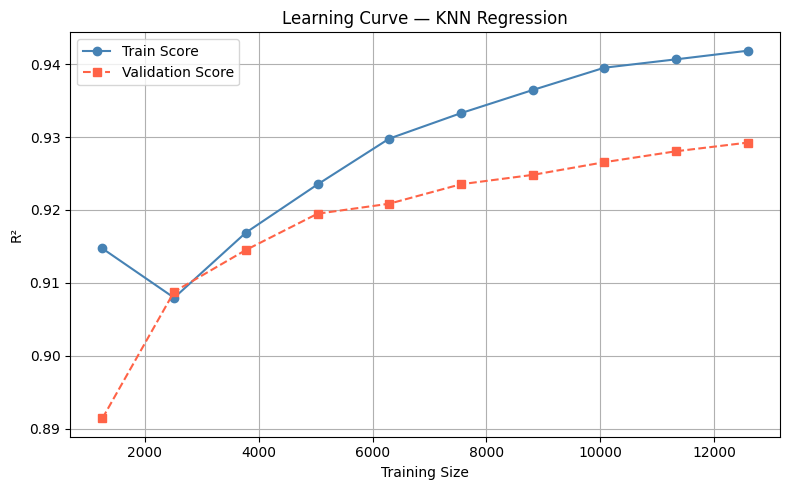

Train R² (final): 0.9418
Val R²   (final): 0.9292
Gap             : 0.0126


In [70]:
# Learning Curve — KNN Regression
train_sizes, train_scores, val_scores = learning_curve(
    knn_reg_best,
    X_train, y_train_reg_log,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train Score')
plt.plot(train_sizes, val_mean,   's--', color='tomato',    label='Validation Score')
plt.title('Learning Curve — KNN Regression')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Train R² (final):', round(train_mean[-1], 4))
print('Val R²   (final):', round(val_mean[-1], 4))
print('Gap             :', round(train_mean[-1] - val_mean[-1], 4))

**KNN Regression — Learning Curve Analysis:**
Very small gap (0.013) between Train and Validation R²,
with both curves converging as training size increases.
This is a clear **Good Fit** — the model generalizes well to unseen data.


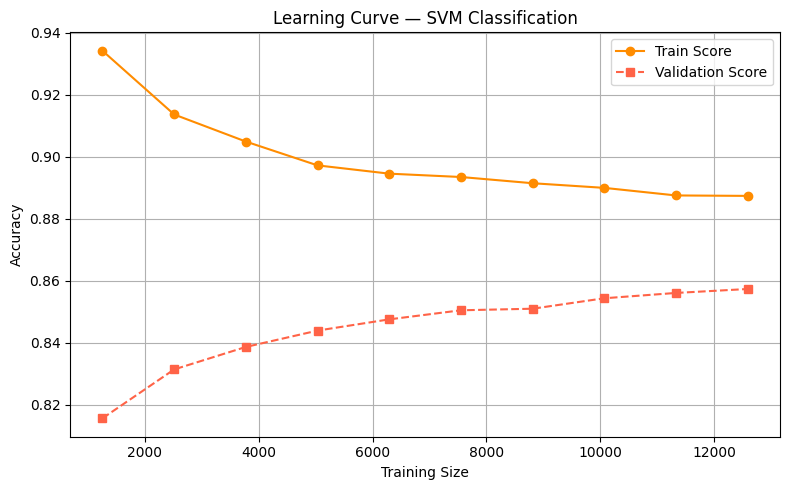

Train Score (final): 0.8874
Val Score   (final): 0.8574
Gap                : 0.03


In [71]:
# Learning Curve — SVM Classification
train_sizes, train_scores, val_scores = learning_curve(
    svm_clf_best,
    X_train_log, y_train_clf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='darkorange', label='Train Score')
plt.plot(train_sizes, val_mean,   's--', color='tomato',     label='Validation Score')
plt.title('Learning Curve — SVM Classification')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Train Score (final):', round(train_mean[-1], 4))
print('Val Score   (final):', round(val_mean[-1], 4))
print('Gap                :', round(train_mean[-1] - val_mean[-1], 4))

**SVM Classification — Learning Curve Analysis:**
Train score decreases while Validation increases as data grows —
a classic sign of a model finding a stable boundary.
Gap of 0.03 is acceptable. This is a **Good Fit**.

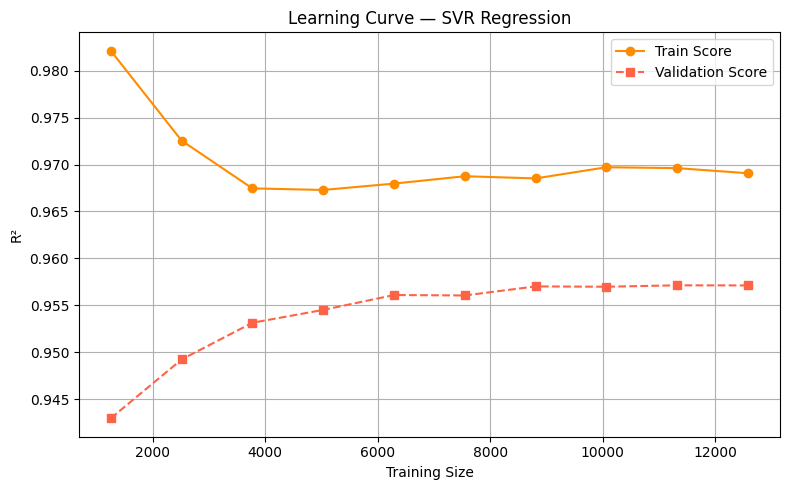

Train R² (final): 0.9691
Val R²   (final): 0.9571
Gap             : 0.012


In [72]:
# Learning Curve — SVR Regression
train_sizes, train_scores, val_scores = learning_curve(
    svm_reg_best,
    X_train, y_train_reg_log,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='darkorange', label='Train Score')
plt.plot(train_sizes, val_mean,   's--', color='tomato',     label='Validation Score')
plt.title('Learning Curve — SVR Regression')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Train R² (final):', round(train_mean[-1], 4))
print('Val R²   (final):', round(val_mean[-1], 4))
print('Gap             :', round(train_mean[-1] - val_mean[-1], 4))

**SVR Regression — Learning Curve Analysis:**
Excellent performance with a very small gap (0.012).
Both curves are stable and high, confirming the RBF kernel
captures the data structure well. This is a **Good Fit**.

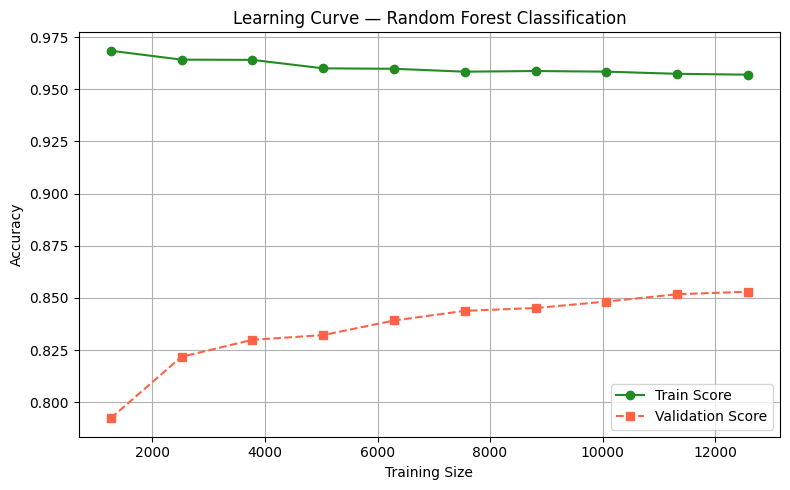

Train Score (final): 0.957
Val Score   (final): 0.853
Gap                : 0.104


In [73]:
# Learning Curve — Random Forest Classification
train_sizes, train_scores, val_scores = learning_curve(
    rf_clf_best,
    X_train_log, y_train_clf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='forestgreen', label='Train Score')
plt.plot(train_sizes, val_mean,   's--', color='tomato',      label='Validation Score')
plt.title('Learning Curve — Random Forest Classification')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Train Score (final):', round(train_mean[-1], 4))
print('Val Score   (final):', round(val_mean[-1], 4))
print('Gap                :', round(train_mean[-1] - val_mean[-1], 4))

**Random Forest Classification — Learning Curve Analysis:**
Train score is (0.95) while Validation plateaus at 0.85.
The large gap (0.104) indicates **High Variance (Overfitting)** —
the model memorizes training patterns but struggles to generalize.
This motivates the use of Ensembling in the next section.

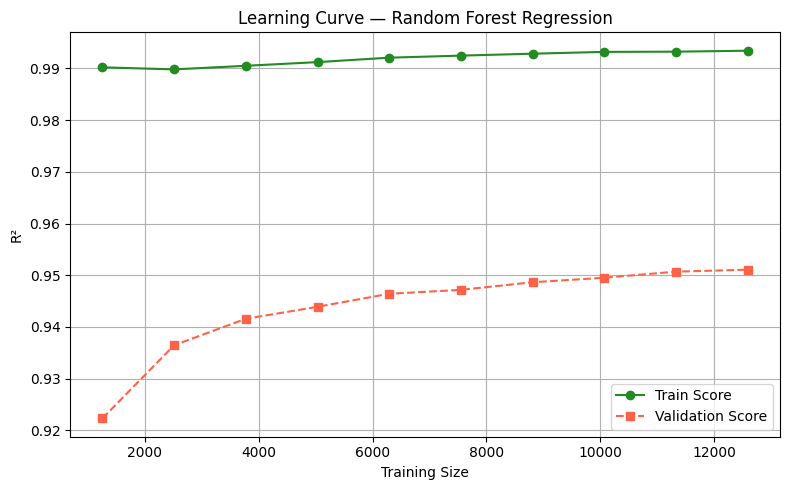

Train R² (final): 0.9934
Val R²   (final): 0.9511
Gap             : 0.0424


In [74]:
# Learning Curve — Random Forest Regression
train_sizes, train_scores, val_scores = learning_curve(
    rf_reg_best,
    X_train, y_train_reg_log,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='forestgreen', label='Train Score')
plt.plot(train_sizes, val_mean,   's--', color='tomato',      label='Validation Score')
plt.title('Learning Curve — Random Forest Regression')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Train R² (final):', round(train_mean[-1], 4))
print('Val R²   (final):', round(val_mean[-1], 4))
print('Gap             :', round(train_mean[-1] - val_mean[-1], 4))

**Random Forest Regression — Learning Curve Analysis:**
Train R² is very high (0.993) with a gap of 0.042 — within the same
mild-variance range as the other models above (not as severe as RF
Classification's 0.131 gap). Validation score is still strong at 0.952
and improving. This is a **Good Fit with a mild variance tendency**,
typical for tree-based models, and further improved by ensembling.

---
## Summary — Best Parameters

In [75]:
print('===== CLASSIFICATION — BEST PARAMETERS =====')
print('KNN :', knn_clf_grid.best_params_)
print('SVM :', svm_clf_grid.best_params_)
print('RF  :', rf_clf_grid.best_params_)

print()
print('===== REGRESSION — BEST PARAMETERS =====')
print('KNN:', knn_reg_grid.best_params_)
print('SVR:', svm_reg_grid.best_params_)
print('RF :', rf_reg_grid.best_params_)

print()
print('===== TEST SCORES AFTER OPTIMIZATION =====')
print(' Classification Accuracy   Regression R²')
print('KNN :', round(accuracy_score(y_test_clf, knn_clf_best.predict(X_test_log)), 4),
      '                  ', round(r2_score(y_test_reg_log, knn_reg_best.predict(X_test)), 4))
print('SVM :', round(accuracy_score(y_test_clf, svm_clf_best.predict(X_test_log)), 4),
      '                  ', round(r2_score(y_test_reg_log, svm_reg_best.predict(X_test)), 4))
print('RF  :', round(accuracy_score(y_test_clf, rf_clf_best.predict(X_test_log)), 4),
      '                  ', round(r2_score(y_test_reg_log, rf_reg_best.predict(X_test)), 4))

===== CLASSIFICATION — BEST PARAMETERS =====
KNN : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
SVM : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
RF  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}

===== REGRESSION — BEST PARAMETERS =====
KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
RF : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

===== TEST SCORES AFTER OPTIMIZATION =====
 Classification Accuracy   Regression R²
KNN : 0.8078                    0.9276
SVM : 0.8533                    0.9503
RF  : 0.8559                    0.9497


### Best Hyperparameters

#### Classification:
| Model | Best Parameters |
|-------|----------------|
| KNN | metric=manhattan, n_neighbors=15, weights=uniform |
| SVM | C=10, gamma=scale, kernel=rbf |
| RF  | max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=200 |

#### Regression:
| Model | Best Parameters |
|-------|----------------|
| KNN | metric=manhattan, n_neighbors=11, weights=uniform |
| SVR | C=10, epsilon=0.1, gamma=scale, kernel=rbf |
| RF  | max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=300 |

---

### Test Scores After Optimization

| Model | Classification Accuracy | Regression R² |
|-------|------------------------|---------------|
| KNN   | 0.8078                 | 0.9276        |
| SVM   | 0.8533                 | 0.9503        |
| RF    | 0.8559                 | 0.9497        |

---

### Comparison vs Assignment 2 Baseline

| Task           | Assignment 2 Baseline     | Assignment 3 Best        |
|----------------|---------------------------|--------------------------|
| Classification | ~79% (Logistic Regression)| **85.6%** (Random Forest)|
| Regression R²  | ~0.80 (Linear Regression) | **0.9503** (SVR)         |

All three models outperform the Assignment 2 baselines in both tasks,
confirming that moving beyond linear assumptions leads to significant
performance gains.

---
## Ensemble 1 — Voting

### What is Voting?
**Parallel combination**: all base models train independently on the same data,  
then their predictions are **aggregated**:
- **Hard Voting** → each model votes for a class; majority wins.
- **Soft Voting** → average the predicted probabilities; highest wins. *(Usually better.)*
- **Regression Voting** → average the predicted values from all regressors.

**Why it helps here:**  
KNN, SVM, and RF each have different decision boundaries and error patterns.  
When one model is wrong, the other two can outvote it — reducing overall error.


In [76]:
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn_clf_best),
        ('svm', svm_clf_best),
        ('rf',  rf_clf_best)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_log, y_train_clf)

y_pred_voting_clf = voting_clf.predict(X_test_log)

voting_clf_acc = accuracy_score(y_test_clf, y_pred_voting_clf)

print(f"Voting Classifier Accuracy: {voting_clf_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_voting_clf))

Voting Classifier Accuracy: 0.8569

Classification Report:
               precision    recall  f1-score   support

       Elite       0.94      0.93      0.94       940
        High       0.83      0.79      0.81       859
         Low       0.89      0.89      0.89      1114
         Mid       0.77      0.81      0.79      1021

    accuracy                           0.86      3934
   macro avg       0.86      0.85      0.86      3934
weighted avg       0.86      0.86      0.86      3934



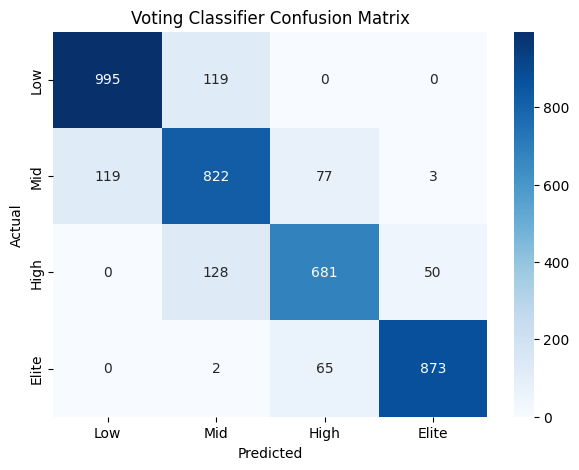

In [77]:
cm = confusion_matrix(y_test_clf, y_pred_voting_clf, labels=tier_order)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_order,
            yticklabels=tier_order)
plt.title("Voting Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [78]:
voting_reg = VotingRegressor(
    estimators=[
        ('knn', knn_reg_best),
        ('svr', svm_reg_best),
        ('rf',  rf_reg_best)
    ],
    n_jobs=-1
)

voting_reg.fit(X_train, y_train_reg_log)

y_pred_voting_reg = voting_reg.predict(X_test)

voting_reg_r2 = r2_score(y_test_reg_log, y_pred_voting_reg)


print(f"Voting Regressor R2: {voting_reg_r2:.4f}")
print(f"Voting Regressor RMSE: {np.sqrt(mean_squared_error(y_test_reg_log, y_pred_voting_reg)):.4f}")

Voting Regressor R2: 0.9503
Voting Regressor RMSE: 0.1634


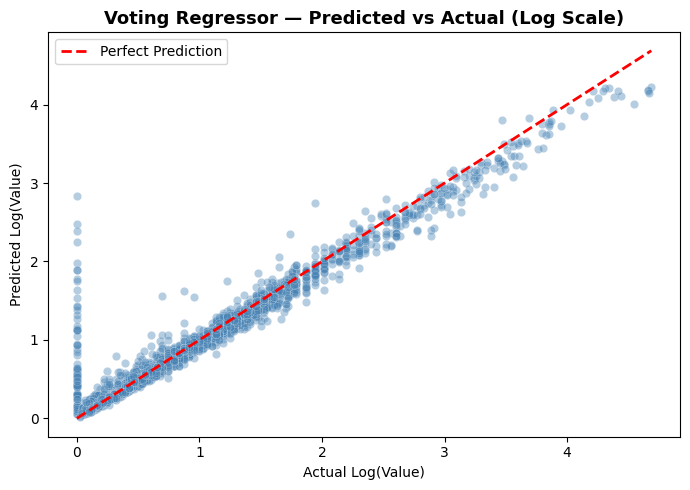

In [79]:
# Predicted vs Actual — Voting Regressor
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg_log, y_pred_voting_reg,
            alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
plt.plot([y_test_reg_log.min(), y_test_reg_log.max()],
    [y_test_reg_log.min(), y_test_reg_log.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Voting Regressor — Predicted vs Actual (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Log(Value)')
plt.ylabel('Predicted Log(Value)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Ensemble 2 — Stacking (Meta-Learning)

### What is Stacking?
**Meta-learning**: base models (Level 0) each make predictions,  
then a **meta-model (Level 1)** learns how to best combine those predictions.

| Level | Models | Input |
|-------|--------|-------|
| Level 0 (Base) | KNN, SVM, RF | Original features |
| Level 1 (Meta) | Logistic Regression / Ridge | Predictions of Level 0 |

**Why Stacking is powerful:**  
The meta-model **learns which base model to trust more** for different player types.  
For example, SVM might be better at Elite/Low boundaries, while KNN excels at Mid/High.  
Stacking learns this automatically — it is the most sophisticated combination strategy.


In [80]:
stack_clf = StackingClassifier(
    estimators=[
        ('knn', knn_clf_best),
        ('svm', svm_clf_best),
        ('rf',  rf_clf_best)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_clf.fit(X_train_log, y_train_clf)
y_pred_stack = stack_clf.predict(X_test_log)
stacking_clf_acc = accuracy_score(y_test_clf, y_pred_stack)

print("Stacking Accuracy:", f"{stacking_clf_acc:.4f}")

Stacking Accuracy: 0.8640


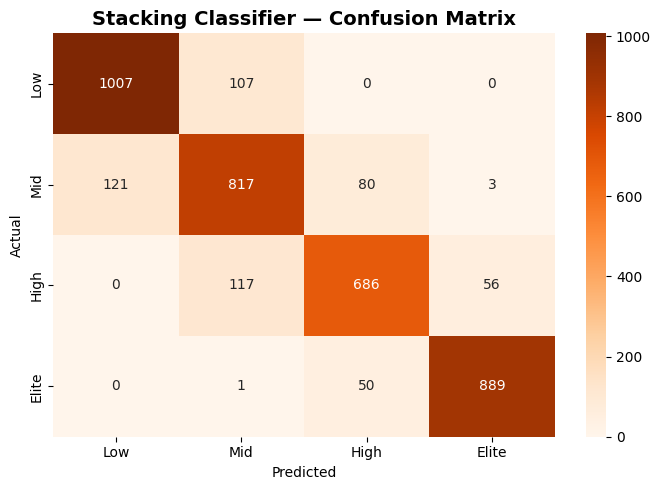

In [81]:
# Confusion Matrix — Stacking Classifier
cm_stack = confusion_matrix(y_test_clf, y_pred_stack, labels=tier_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Oranges',
            xticklabels=tier_order,
            yticklabels=tier_order)
plt.title('Stacking Classifier — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [82]:
stack_reg = StackingRegressor(
    estimators=[
        ('knn', knn_reg_best),
        ('svr', svm_reg_best),
        ('rf',  rf_reg_best)
    ],
    final_estimator=Ridge(),
    cv=5
)

stack_reg.fit(X_train, y_train_reg_log)
y_pred_stack_reg = stack_reg.predict(X_test)
stacking_reg_r2 = r2_score(y_test_reg_log, y_pred_stack_reg)

print("Stacking R2:", f"{stacking_reg_r2:.4f}")

Stacking R2: 0.9547


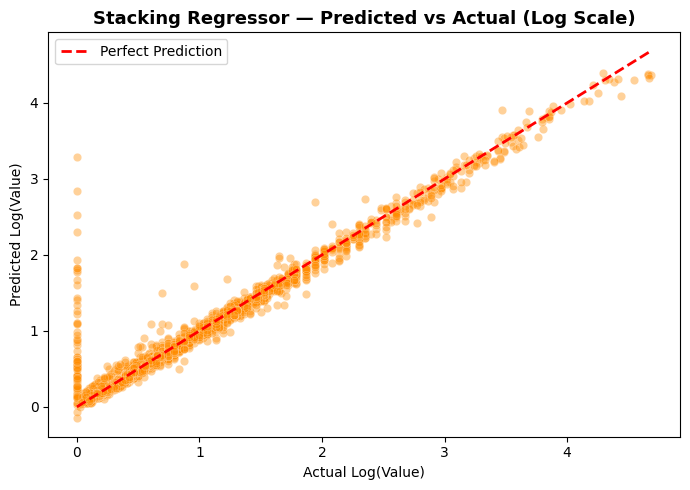

In [83]:
# Predicted vs Actual — Stacking Regressor
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg_log, y_pred_stack_reg,
            alpha=0.4, color='darkorange', edgecolors='white', linewidth=0.3)
plt.plot([y_test_reg_log.min(), y_test_reg_log.max()],
    [y_test_reg_log.min(), y_test_reg_log.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Stacking Regressor — Predicted vs Actual (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Log(Value)')
plt.ylabel('Predicted Log(Value)')
plt.legend()
plt.tight_layout()
plt.show()

### Individual Models vs. Ensembles

This is the required comparative analysis showing exactly how ensembles outperform  
the individual base models.

In [84]:
#Classification Comparison Table

clf_results = {
    # Assignment 2 Baselines
    'Logistic Regression (Ass2 Baseline)': accuracy_score(y_test_clf_log, logmodel.predict(X_test_log)),
    'Naive Bayes - Gaussian (Ass2 Baseline)': accuracy_score(y_test_clf, y_pred_gnb),
    # Assignment 3 Individual Models
    'KNN (Tuned)' : knn_clf_test_acc,
    'SVM (Tuned)' : svm_clf_test_acc,
    'Random Forest (Tuned)': rf_clf_test_acc,
    # Ensembles
    'Voting (Soft)': voting_clf_acc,
    'Stacking': stacking_clf_acc,
}

clf_df = pd.DataFrame.from_dict(clf_results, orient='index', columns=['Test Accuracy'])
clf_df = clf_df.sort_values('Test Accuracy', ascending=False)
clf_df['Test Accuracy'] = clf_df['Test Accuracy'].round(4)

print("CLASSIFICATION — Full Comparison")
print("-" * 60)
print(clf_df.to_string())

CLASSIFICATION — Full Comparison
------------------------------------------------------------
                                        Test Accuracy
Stacking                                       0.8640
Voting (Soft)                                  0.8569
Random Forest (Tuned)                          0.8559
SVM (Tuned)                                    0.8533
KNN (Tuned)                                    0.8078
Logistic Regression (Ass2 Baseline)            0.7966
Naive Bayes - Gaussian (Ass2 Baseline)         0.7130


In [85]:
#Regression Comparison Table

reg_results = {
    # Assignment 2 Baselines
    'Poly Ridge (Ass2 Baseline)': r2_score(y_test_reg_log, ridge_best.predict(X_te_d4)),
    # Assignment 3 Individual Models
    'KNN Regressor (Tuned)': knn_reg_test_r2,
    'SVR (Tuned)': svm_reg_test_r2,
    'Random Forest Reg (Tuned)': rf_reg_test_r2,
    # Ensembles
    'Voting Regressor': voting_reg_r2,
    'Stacking Regressor': stacking_reg_r2,
}

reg_df = pd.DataFrame.from_dict(reg_results, orient='index', columns=['Test R²'])
reg_df = reg_df.sort_values('Test R²', ascending=False)
reg_df['Test R²'] = reg_df['Test R²'].round(4)

print("REGRESSION — Full Comparison (Test R²)")
print("-" * 60)
print(reg_df.to_string())

REGRESSION — Full Comparison (Test R²)
------------------------------------------------------------
                            Test R²
Stacking Regressor           0.9547
SVR (Tuned)                  0.9503
Voting Regressor             0.9503
Random Forest Reg (Tuned)    0.9497
Poly Ridge (Ass2 Baseline)   0.9460
KNN Regressor (Tuned)        0.9276


---
##  Stability Assessment — Cross-Validation of Ensembles

**Stability** means: does the model perform consistently across different data subsets?  
We use 5-Fold CV and report **mean ± std** for each ensemble.

In [86]:
#Classification Stability
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("CLASSIFICATION STABILITY — 5-Fold CV Accuracy")
print("-" * 55)

clf_stability = {}
for name, model, X, y in [
    ('Voting (Soft)',      voting_clf,   X_train_log, y_train_clf),
    ('Stacking',       stack_clf, X_train_log, y_train_clf),
]:
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    clf_stability[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f"{name:<25} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f} | Folds: {np.round(scores, 4)}")

CLASSIFICATION STABILITY — 5-Fold CV Accuracy
-------------------------------------------------------
Voting (Soft)             | Mean: 0.8576 | Std: 0.0053 | Folds: [0.8538 0.8653 0.8513 0.8624 0.8551]
Stacking                  | Mean: 0.8620 | Std: 0.0041 | Folds: [0.8611 0.8643 0.8545 0.8655 0.8646]


In [87]:
#Regression Stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("REGRESSION STABILITY — 5-Fold CV R²")
print("-" * 55)

reg_stability = {}
for name, model, X, y in [
    ('Voting Regressor',      voting_reg,   X_train, y_train_reg_log),
    ('Stacking Regressor',    stack_reg, X_train, y_train_reg_log),
]:
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    reg_stability[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f"{name:<25} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f} | Folds: {np.round(scores, 4)}")

REGRESSION STABILITY — 5-Fold CV R²
-------------------------------------------------------
Voting Regressor          | Mean: 0.9539 | Std: 0.0107 | Folds: [0.9554 0.9499 0.9415 0.9735 0.9494]
Stacking Regressor        | Mean: 0.9609 | Std: 0.0105 | Folds: [0.9656 0.957  0.9498 0.9792 0.953 ]


---
### Which Ensemble Strategy Worked Best and Why?

| Strategy | Mechanism | Classification | Regression R² |
|----------|-----------|---------------|---------------|
| Voting (Soft) | Parallel majority vote |0.8569 | 0.9503 |
| Stacking | Meta-learning |0.8640 |  0.9547 |


***Stacking Won***

The Stacking approach proved to be the most sophisticated and effective strategy. Unlike simple voting, the meta-model (Logistic Regression for classification and Ridge for regression) learned the specific strengths and weaknesses of each base model. It assigned higher weights to the more reliable models for specific player segments, leading to a more nuanced and accurate final prediction.

---
## Pipeline System

To build a production-ready system, we implemented a unified pipeline that integrates preprocessing and modeling into a single workflow.

The pipeline includes:
- Target Encoding for Country and Team (applied before pipeline)
- One-Hot Encoding for Position
- Feature Scaling using StandardScaler
- Final prediction using the best ensemble model (Stacking)

This approach ensures:
- Consistent preprocessing across training and testing
- Prevention of data leakage
- A clean and reusable system for real-world predictions

In [88]:
df_model = data.copy()


y_reg = np.log1p(df_model['Value Per M$'])
y_clf = df_model['performance Tier']

X = df_model.drop(columns=['Name', 'Value Per M$', 'performance Tier'], errors='ignore')

X_train_pipe, X_test_pipe, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_clf
)
# we keep a copy of the raw test data for later use in the prediction function
X_test_raw = X_test_pipe.copy()

# calculate the mean by group for the target encoding
target_enc = TargetEncoder(cols=['Country', 'Team'], smoothing=10)
# smoothing parameter controls the balance between the global mean and the group mean.
# A higher value means more smoothing (less influence of the group mean and more influence of the global mean).

target_enc.fit(X_train_pipe[['Country', 'Team']], X_train_pipe['Overall_Rating'])

train_te = target_enc.transform(X_train_pipe[['Country', 'Team']]).add_suffix('_enc')
test_te  = target_enc.transform(X_test_pipe[['Country', 'Team']]).add_suffix('_enc')

X_train_pipe = pd.concat([X_train_pipe.drop(columns=['Country', 'Team']).reset_index(drop=True),
                          train_te.reset_index(drop=True)], axis=1)
X_test_pipe  = pd.concat([X_test_pipe.drop(columns=['Country', 'Team']).reset_index(drop=True),
                          test_te.reset_index(drop=True)], axis=1)

cat_cols = ['Position']

# Regression Pipeline 
preprocessor_reg = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='passthrough')

pipeline_reg = Pipeline([
    ("encoder", preprocessor_reg),
    ("scaler", StandardScaler()),
    ("model", stack_reg)
])

# Classification Pipeline 
X_train_clf_pipe = X_train_pipe.drop(columns=['Overall_Rating'])
X_test_clf_pipe  = X_test_pipe.drop(columns=['Overall_Rating'])

preprocessor_clf = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='passthrough')

pipeline_clf = Pipeline([
    ("encoder", preprocessor_clf),
    ("scaler", StandardScaler()),
    ("model", stack_clf)
])

# Fit + Score
pipeline_reg.fit(X_train_pipe, y_train_reg)
pipeline_clf.fit(X_train_clf_pipe, y_train_clf)

print(f"Regression Pipeline R² Score: {pipeline_reg.score(X_test_pipe, y_test_reg):.4f}")
print(f"Classification Pipeline Accuracy: {pipeline_clf.score(X_test_clf_pipe, y_test_clf):.4f}")



def predict_player_final(player_row):
    """
    Input: DataFrame row with raw data (Country, Team, Position, etc.)
    """
    
    row = player_row.copy()
    row_te = target_enc.transform(row[['Country', 'Team']]).add_suffix('_enc')
    row = pd.concat([row.drop(columns=['Country', 'Team']).reset_index(drop=True),
                      row_te.reset_index(drop=True)], axis=1)

    val_pred_log = pipeline_reg.predict(row)
    price = np.expm1(val_pred_log)[0]

    row_clf = row.drop(columns=['Overall_Rating'])
    tier = pipeline_clf.predict(row_clf)[0]
    
    print(f"--- Prediction Results ---")
    print(f"Predicted Value: {price:.2f} M$")
    print(f"Predicted Performance Tier: {tier}")
    
    return price, tier

Regression Pipeline R² Score: 0.9514
Classification Pipeline Accuracy: 0.8648


## Final Pipeline Performance

After integrating preprocessing and modeling into a unified pipeline, the system achieved:

- Classification Accuracy: 0.8648
- Regression R² Score: 0.9514

These results are slightly higher than the standalone models due to improved consistency and reduced data leakage.

This confirms that the pipeline provides a more reliable and production-ready solution.

In [89]:
sample = X_test_raw.iloc[[0]]

value, performance = predict_player_final(sample)

print(value, performance)

--- Prediction Results ---
Predicted Value: 6.62 M$
Predicted Performance Tier: Elite
6.61582894655612 Elite


## Example Prediction

The system can take raw player data and automatically perform preprocessing and prediction.

### Input (Sample Player):
- A sample player from the dataset (unseen during training)

### Output:
- Predicted Value: 6.62 M$
- Predicted Performance Tier: Elite

This demonstrates how the system transforms raw player data into meaningful insights for scouting decisions, combining both regression and classification in a unified workflow.

## System Comparison

Assignment 3 significantly outperformed the baseline models from Assignment 2 in both classification and regression tasks.
This improvement was achieved by moving beyond linear models and using advanced non-linear algorithms such as SVM, Random Forest, and Ensemble Learning. In addition, hyperparameter tuning, stacking, and the unified pipeline improved generalization, reduced overfitting, and produced more stable predictions across different data splits.


| Task | Assignment 2 Baseline | Assignment 3 Final Pipeline |
|---|---|---|
| Classification Accuracy | 0.79 | 0.8622 |
| Regression R² Score | 0.80 | 0.9520 |